# INTRODUCCION

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estás pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

# OBJETIVOS

## Objetivo General

* Identificar los patrones de comportamiento y características clave en la tienda online ICE que permitan determinar qué factores influyen en el éxito o fracaso de un videojuego.
  

## Objetivo Específico

* Identificar videojuegos con alto potencial de éxito comercial mediante el análisis de variables clave presentes en los datos históricos.

* Diseñar estrategias de marketing y campañas publicitarias más efectivas para el año 2017, basadas en patrones de comportamiento del mercado y preferencias de los usuarios.

* Desarrollar modelos predictivos que permitan estimar la probabilidad de éxito de un videojuego utilizando información histórica disponible hasta el año 2016.


# PLAN DE ANALISIS

**1. Carga, integración y limpieza de datos:**

Importar los conjuntos de datos, revisar la calidad de la información, gestionar valores faltantes, corregir tipos de datos y estandarizar variables para garantizar la consistencia del análisis.

**2. Cálculo y generación de variables relevantes:**

Calcular las ventas totales por videojuego a partir de las ventas regionales, así como crear variables derivadas que faciliten el análisis del rendimiento comercial.

**3. Análisis exploratorio de datos (EDA):**
   
Explorar y visualizar los patrones de ventas entre diferentes plataformas, géneros y regiones, identificando tendencias, comportamientos atípicos y factores potencialmente asociados al éxito de los videojuegos.

**4. Análisis estadístico y pruebas de hipótesis:**
   
Aplicar métodos estadísticos para evaluar diferencias significativas entre grupos por ejemplo, plataformas o géneros, y validar las relaciones observadas en los datos mediante pruebas de hipótesis.

**5. Interpretación de resultados y conclusiones:**
   
Integrar los hallazgos obtenidos para identificar factores determinantes del éxito de un videojuego y generar recomendaciones estratégicas para la toma de decisiones comerciales.

# Paso 1: Carga de datos

In [1]:
# Cargar todas las librerías

import pandas as pd                                         
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math as mt
from math import factorial
from scipy import stats as st

In [2]:
# Cargar archivo

df_games = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_6/games.csv")

In [3]:
# Validación completa del DataFrame

print('-' * 50)
print(f"DataSet: {df_games.shape[0]:,} filas y {df_games.shape[1]} columnas ")
print('-' * 50)
print(f"Valores duplicados: {df_games.duplicated().sum()}")
print('-' * 50)
print('Información del Dataset Games')
print(df_games.info())
print('-' * 50)
print('Datos ausentes de la tabla Games')
print(df_games.isna().sum())
print("-" * 50)
print('Descripción general de la tabla')
print(df_games.describe())

--------------------------------------------------
DataSet: 16,715 filas y 11 columnas 
--------------------------------------------------
Valores duplicados: 0
--------------------------------------------------
Información del Dataset Games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

In [4]:
print('Muestras Aleatorias del DataSet Games')
print('-' * 50)
print(df_games.sample(10))

Muestras Aleatorias del DataSet Games
--------------------------------------------------
                                           Name Platform  Year_of_Release  \
917                Yu-Gi-Oh! Forbidden Memories       PS           1999.0   
12683  Exist Archive: The Other Side of the Sky      PSV           2015.0   
322       The Legend of Zelda: Link's Awakening       GB           1992.0   
11828        Damage Inc.: Pacific Squadron WWII     X360           2012.0   
3801                   How to Train Your Dragon       DS           2010.0   
6364                    Despicable Me: The Game      Wii           2010.0   
15341                               Veggy World       DS           2011.0   
11636                        Samurai Warriors 2     X360           2006.0   
5412                The Sims 3: Town Life Stuff       PC           2011.0   
1562   Jillian Michaels' Fitness Ultimatum 2009      Wii           2008.0   

              Genre  NA_sales  EU_sales  JP_sales  Other_sales 

## Observaciones en la tabla 'Games'

**Estructura General:**

* DataSet con 16,715 filas y 11 columnas.

**Problemas encontrados y correcciones aplicadas:**

**1. Inconsistencias en el formato de texto.**

* Los nombres de las columnas presentan una descripción clara y eficaz, pero es necesario colocarlo en minúscula.

* **Solución:** Estandarizar a minúsculas con .str.lower().str.strip()

**2. Valores ausentes (NaN) no estandarizados.**

* Los faltantes de las columnas pueden aparecer de formas diferentes o como cadenas vacías.

* **Solución:** Estandarizar con el método .replace() buscando todos los diferentes tipos de "valores faltantes" ('nan', 'Nan', 'NaN', 'null', 'NULL), pasando al formato estándar np.nan.

* Los valores ausentes en la columna rating, serán remplazados por la categoría 'sin clasificar', con el fin de mantener visibles en el análisis. Esto es importante porque 6766 registros es una cantidad significativa y descartarlos podría sesgar los resultados.

* **Solución:** Utilizar el método fillna () que permita rellenar los valores NaN con la nueva categoría.

**3. Tipo de datos inadecuados:**

* Las columna year_of_release y critic_score, son de tipo float64, deberían ser de tipo Int64.

* **Solución:** Convertir usando el método .astype().

**Ventajas de usar Int64 sobre float64**

  
* Para la columna *Year_of_Release*, los valores representan únicamente años, sin información de día o mes, lo que impide convertirlos directamente al tipo DateTime. Al tratarse de un identificador temporal incompleto, lo más adecuado es manejarlos como enteros (Int64).

* En cuanto a la columna *Critic_Score*, según la descripción estadística de los datos, sus valores se encuentran en un rango entero entre 13 y 98, sin presencia de decimales, por lo que almacenarlos como Int64 es la representación más precisa y eficiente para este tipo de dato.

## Paso 2: Preparar Datos

### 2.1. Corrección de datos

In [5]:
# 1. Convertir nombres de columnas a minúscula

df_games.columns = df_games.columns.str.lower().str.strip()
print('Columnas en minúsculas')
print(df_games.columns)
print('-' * 50)

# 2. Estandarizar valores nulos

df_games = df_games.replace(['nan', 'Nan', 'NaN', 'null', 'NULL',''], np.nan)
print('Valores nulos del Dataframe')
print(df_games.isna().sum())
print('Nota: Los valores faltantes en el Dataset ya eran np.nan (no string), \npor eso se mantienen igual.')
print('-' * 50)

# 3 .Convertir columnas a tipo Int64

df_games[['year_of_release', 'critic_score']] = df_games[['year_of_release', 'critic_score']].astype('Int64')

print('Tipo de columnas:')
print(f"La columna year_of_release es de tipo: {df_games['year_of_release'].dtype}")
print(f"La columna critic_score es de tipo: {df_games['critic_score'].dtype}")

Columnas en minúsculas
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')
--------------------------------------------------
Valores nulos del Dataframe
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64
Nota: Los valores faltantes en el Dataset ya eran np.nan (no string), 
por eso se mantienen igual.
--------------------------------------------------
Tipo de columnas:
La columna year_of_release es de tipo: Int64
La columna critic_score es de tipo: Int64


### 2.2. Enriquecer Datos

**Columnas Nuevas**

1. Total de ventas (total_sale)

* Se crea una nueva **columna total_sale** que representa la suma de ventas de todas las regiones disponibles para cada juego, permitiendo tener una visión global del rendimiento comercial de cada uno.

  
2. Tratamiento de la columna User_Score

* La columna presenta tres tipos de valores distintos: datos ausentes (NaN), valores tbd (to be determined) y números decimales.

* **Solución:** Se crea dos nuevas columna que separen los registros con valor tbd y las críticas (0-10). Esto es necesario porque los valores tbd son de tipo object (cadena de texto), lo que impide realizar operaciones estadísticas sobre la columna sin generar errores.

**¿Qué significa tbd?**

* El valor to be determined indica que el juego aún no cuenta con una puntuación de usuarios definida. Esto puede deberse a dos razones principales:

1. Insuficiencia de reseñas: Las plataformas requieren un mínimo de valoraciones para calcular un promedio representativo. Mientras no se alcance ese umbral, la puntuación permanece como tbd.
   
2. Juego recién lanzado: En títulos nuevos o en preventa, los usuarios aún no han tenido el tiempo necesario para jugar y evaluar el producto.


In [6]:
# Observar el conteo de valores NaN Y tbd

df_games['user_score'].value_counts(dropna=False)

user_score
NaN    6701
tbd    2424
7.8     324
8       290
8.2     282
       ... 
1.3       2
1         2
0.9       2
0         1
9.7       1
Name: count, Length: 97, dtype: int64

In [7]:
# Columna rating nueva rellenar valores ausentes con nueva categoría 'sin clasificar'
df_games['rating'] = df_games['rating'].fillna('Sin_Clasificar')
df_games['rating'].value_counts(dropna=False)


rating
Sin_Clasificar    6766
E                 3990
T                 2961
M                 1563
E10+              1420
EC                   8
K-A                  3
RP                   3
AO                   1
Name: count, dtype: int64

In [8]:
# Agrupar categorías menores en 'Other'
main_categories = ['E', 'T', 'M', 'E10+', 'Sin_Clasificar']
df_games['rating'] = df_games['rating'].apply(
    lambda x: x if x in main_categories else 'Others'
)

df_games['rating'].value_counts()

rating
Sin_Clasificar    6766
E                 3990
T                 2961
M                 1563
E10+              1420
Others              15
Name: count, dtype: int64

In [9]:
# Crear columna con valores tbd (to be determined).

df_games['to_be_determined'] = df_games['user_score'].where(df_games['user_score'] == 'tbd') 


print("Conteo de valores en la nueva columna:")
print(df_games['to_be_determined'].value_counts(dropna=False))
print('-' * 50)
print(f"\nTotal de 'tbd': {df_games['to_be_determined'].notna().sum()}")
print(f"Total de NaN: {df_games['to_be_determined'].isna().sum()}")

Conteo de valores en la nueva columna:
to_be_determined
NaN    14291
tbd     2424
Name: count, dtype: int64
--------------------------------------------------

Total de 'tbd': 2424
Total de NaN: 14291


In [10]:
# Crear columna con los valores de críticas

#Convertir user_score a numérico primero
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')
# ↑ 'tbd' y cualquier texto → NaN

df_games['only_user_score'] = df_games['user_score'].where((df_games['user_score'] >=0) & (df_games['user_score'] <=10))  


print(f"Total juegos              : {len(df_games)}")
print(f"Valores válidos (0–10)    : {df_games['only_user_score'].notna().sum()}")
print(f"Valores NaN/tbd/inválidos : {df_games['only_user_score'].isna().sum()}")
print('-' * 50)
print(f"Mínimo valor              : {df_games['only_user_score'].min()}")
print(f"Máximo valor              : {df_games['only_user_score'].max()}")
print(f"Valores únicos fuera rango: {df_games['user_score'][(df_games['user_score'] < 0) | (df_games['user_score'] > 10)].unique()}")

Total juegos              : 16715
Valores válidos (0–10)    : 7590
Valores NaN/tbd/inválidos : 9125
--------------------------------------------------
Mínimo valor              : 0.0
Máximo valor              : 9.7
Valores únicos fuera rango: []


In [11]:
# Encontrar todos los valores de texto en user_score 
valores_texto = df_games[
    pd.to_numeric(df_games['user_score'], errors='coerce').isna() &
    df_games['user_score'].notna()
]['user_score'].value_counts()

print(f"Total valores de texto : {valores_texto.sum()}")
print(f"Total 'tbd'            : {df_games['to_be_determined'].notna().sum()}")

# Verificación matemática completa 
nan_originales  = df_games['user_score'].isna().sum()
texto_total     = valores_texto.sum()
nan_only_user   = df_games['only_user_score'].isna().sum()

print('=' * 50)
print('  VERIFICACIÓN MATEMÁTICA')
print('=' * 50)
print(f"NaN originales                : {nan_originales}")
print(f"Valores de texto (todos)      : {texto_total}")
print(f"NaN en only_user_score        : {nan_only_user}")
print(f"NaN originales + texto total  : {nan_originales + texto_total}")
print(f"¿Coincide ahora?              : {nan_originales + texto_total == nan_only_user}")


Total valores de texto : 0
Total 'tbd'            : 2424
  VERIFICACIÓN MATEMÁTICA
NaN originales                : 9125
Valores de texto (todos)      : 0
NaN en only_user_score        : 9125
NaN originales + texto total  : 9125
¿Coincide ahora?              : True


In [12]:
# Cálculo de ventas totales

df_games['total_sale'] = df_games[['na_sales', 'eu_sales','jp_sales', 'other_sales']].sum(axis=1)
print(f'Total de NaN: {df_games['total_sale'].isna().sum()}')
print('-' * 50)
print('Nueva columna: Total de Ventas')
print(df_games['total_sale'].sample(10))


Total de NaN: 0
--------------------------------------------------
Nueva columna: Total de Ventas
2360     0.89
6654     0.25
16346    0.01
11251    0.09
421      3.23
11098    0.09
6128     0.27
9839     0.12
11556    0.08
157      5.58
Name: total_sale, dtype: float64


In [13]:
# Dataframe actualizado
print('DataFrame Actualizado:')
print(df_games.head())


DataFrame Actualizado:
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score          rating  \
0     28.96      3.77         8.45            76         8.0               E   
1      3.58      6.81         0.77          <NA>         NaN  Sin_Clasificar   
2     12.76      3.79         3.29            82         8.3               E   
3     10.93      3.28         2.95            80         8.0               E   
4      8.89     10.22         1.00          <NA>         NaN  Sin_Clasificar   

  to_be_d

## Paso 3: Análisis de Datos

#### 3.1 Contar juegos por año y visualizar la tendencia

Juegos lanzados por año:
El número de juegos mínimo por año es: 9 juegos
El número de juegos máximo por año es: 1427 juegos
Año           Juegos         % del total
--------------------------------------------------
1980            9               0.1%   Pocos datos
1981           46               0.3%   Pocos datos
1982           36               0.2%   Pocos datos
1983           17               0.1%   Pocos datos
1984           14               0.1%   Pocos datos
1985           14               0.1%   Pocos datos
1986           21               0.1%   Pocos datos
1987           16               0.1%   Pocos datos
1988           15               0.1%   Pocos datos
1989           17               0.1%   Pocos datos
1990           16               0.1%   Pocos datos
1991           41               0.2%   Pocos datos
1992           43               0.3%   Pocos datos
1993           62               0.4%   
1994          121               0.7%   
1995          219               1.3% █  


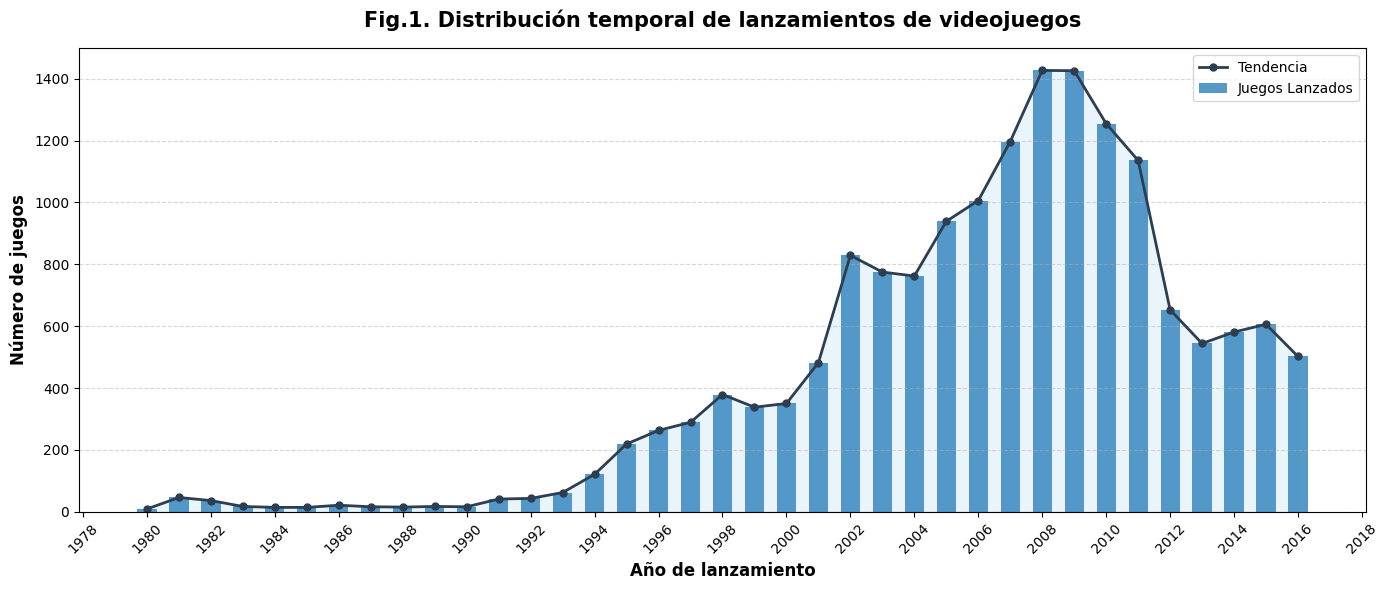

In [14]:
# Análisis de distribución temporal

games_for_year = df_games['year_of_release'].value_counts().sort_index()
print('Juegos lanzados por año:')
print(f"El número de juegos mínimo por año es: {games_for_year.min()} juegos")
print(f"El número de juegos máximo por año es: {games_for_year.max()} juegos")
print('=' * 50)
print(f"{'Año':<10}{'Juegos':>10}{'% del total':>20}")
print('-' * 50)

# Códigos ANSI de color
GREEN = '\033[92m'
RESET = '\033[0m'

green = '\033[92m'
total = games_for_year.sum()
for year, count in games_for_year.items():
    porcent = (count / total) * 100
    bar = '█' * int(porcent)
    color = green
    reset = '\033[0m'
    significance = 'Pocos datos' if count < 50 else ''

    print(f"{int(year):<10} {count:>6}{porcent:>18.1f}% {color}{bar}{reset}  {significance}")

print('-' * 50)
print(f"{'Total':<10} {total:>10} {'100.0%':>14}")
print('=' * 50)


# Filtrar valores NaN y convertir a numpy arrays antes de crear el gráfico
games_for_year_clean = games_for_year.dropna()

x_data = games_for_year_clean.index.to_numpy()
y_data = games_for_year_clean.values.astype(int)

# Gráfica de línea para ver la evolución
fig, ax = plt.subplots(figsize=(14, 6))


ax.bar(x_data, y_data, alpha=0.75, width=0.6, label ='Juegos Lanzados')

ax.plot(x_data, y_data, color='#2c3e50', linewidth=2, marker='o', markersize=5, label='Tendencia')

ax.fill_between(x_data, y_data, alpha=0.1, color='#3498db')

from matplotlib import ticker

ax.set_title('Fig.1. Distribución temporal de lanzamientos de videojuegos',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Año de lanzamiento', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de juegos', fontsize=12, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xticks(rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Descripción de la gráfica 'Distribución temporal de lanzamientos de videojuegos'

**ESTRUCTURA DEL GRAFICO:**

* Eje X (horizontal): Años de lanzamientos de los videojuegos (1978-2018).
* Eje Y (vertical): Número de juegos lanzados por año.

**ANALISIS ESTADISTICO**

* Los datos anteriores a 1994 representan una cantidad muy baja de lanzamientos, no superan los 100 juegos por año.

* A partir del año 1994 se observa un crecimiento progresivo y sostenido en los lanzamientos.

* Los picos altos o máximos se dan en los años 2008-2009 con 1427 juegos, siendo los años con mayor actividad en toda la historia.

* A partir del año 2009 comienzo un descenso gradual, con una caída más pronunciada entre 2011 y 2013, en donde los lanzamientos se reducen casi a la mitad con respecto a los picos máximos.

#### 3.2 Analizar variaciones de ventas entre plataformas

In [15]:
# 1 Identificar las plataformas con mayores ventas totales

plataforms_analysis = df_games.groupby(['platform']).agg({
    'total_sale': 'sum',  # Suma de total_sale
    'name': 'count',   # Cantidad de juegos
    'year_of_release': ['min', 'max']  # Rango de años (año que apareció el 1er juego y último año juego lanzado)
})

plataforms_analysis.columns = ['total_sales', 'games_count', 'frist_year', 'last_year']
plataforms_analysis['total_sales'] = plataforms_analysis['total_sales'].round(2)

plataforms_analysis = plataforms_analysis.sort_values('total_sales', ascending=False)

plataforms_analysis['years_active'] = plataforms_analysis['last_year'] - plataforms_analysis['frist_year']  

print('Top 10 plataformas por ventas totales:')
print(plataforms_analysis.head(10))



Top 10 plataformas por ventas totales:
          total_sales  games_count  frist_year  last_year  years_active
platform                                                               
PS2           1255.77         2161        2000       2011            11
X360           971.42         1262        2005       2016            11
PS3            939.65         1331        2006       2016            10
Wii            907.51         1320        2006       2016            10
DS             806.12         2151        1985       2013            28
PS             730.86         1197        1994       2003             9
GBA            317.85          822        2000       2007             7
PS4            314.14          392        2013       2016             3
PSP            294.05         1209        2004       2015            11
PC             259.52          974        1985       2016            31


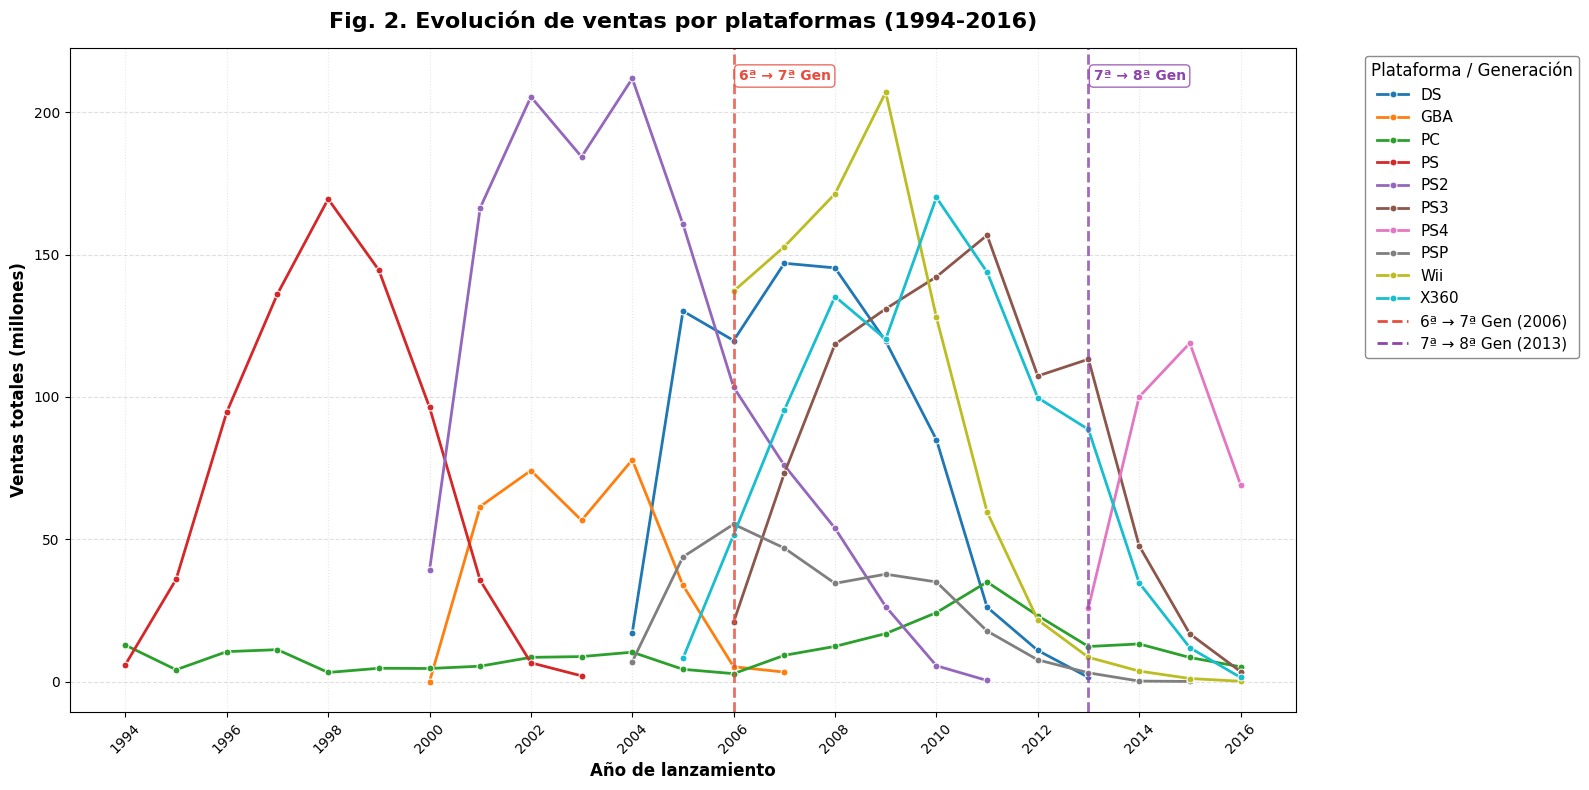

In [16]:
# Gráfica de líneas distribución por año

# Crear datos de ventas por plataforma por año
sales_by_year = df_games.groupby(['platform', 'year_of_release'])['total_sale'].sum().reset_index()

# Filtrar solo el top 10 plataforma
top_plataforms = plataforms_analysis.head(10).index.tolist()
sales_filtered = sales_by_year[
    (sales_by_year['platform'].isin(top_plataforms)) &
    (sales_by_year['year_of_release'] >= 1994) &   # Excluye años con pocos datos
    (sales_by_year['year_of_release'] <= 2016) 
]

# Gráfica de líneas distribución por año

fig, ax = plt.subplots(figsize=(16, 8))
sns.lineplot(
    data = sales_filtered, 
    x = 'year_of_release', 
    y = 'total_sale', 
    hue = 'platform',
    linewidth = 2,
    marker = 'o',
    markersize = 5,
    ax = ax
)

# Línea transición generacional
# Generación 6ª → 7ª

ax.axvline(x=2006, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)
ax.text(2006.1, ax.get_ylim()[1] * 0.95,        # posición del texto
        '6ª → 7ª Gen',
        color='#e74c3c', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c', alpha=0.8))

# Generación 7ª → 8ª
ax.axvline(x=2013, color='#8e44ad', linestyle='--', linewidth=2, alpha=0.8)
ax.text(2013.1, ax.get_ylim()[1] * 0.95,
        '7ª → 8ª Gen',
        color='#8e44ad', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#8e44ad', alpha=0.8))


ax.set_title('Fig. 2. Evolución de ventas por plataformas (1994-2016)',
            fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Año de lanzamiento', fontsize=12, fontweight='bold')
ax.set_ylabel('Ventas totales (millones)', fontsize=12, fontweight='bold' )

# Eje X mostrar cada 2 años para no saturar
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xticks(rotation=45)

# Grilla suave
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.3)

# Handles para las generaciones 

from matplotlib.lines import Line2D

gen_handles = [
    Line2D([0], [0], color='#e74c3c', linestyle='--', linewidth=2,
           label='6ª → 7ª Gen (2006)'),
    Line2D([0], [0], color='#8e44ad', linestyle='--', linewidth=2,
           label='7ª → 8ª Gen (2013)'),
   
]
sns_handles, sns_labels = ax.get_legend_handles_labels()

ax.legend(
    handles       = sns_handles + gen_handles,   # ← seaborn + manuales
    title         = 'Plataforma / Generación',
    bbox_to_anchor= (1.05, 1),
    loc           = 'upper left',
    fontsize      = 11,
    title_fontsize= 12,
    framealpha    = 0.9,
    edgecolor     = 'gray'
)

plt.tight_layout()
plt.show()

In [17]:
# Verificar las ventas anuales de PS2
ps2_annual = df_games[df_games['platform'] == 'PS2'].groupby('year_of_release')['total_sale'].sum()

print("Ventas anuales de PS2:")
print(ps2_annual.sort_values(ascending=False))

max_ventas = ps2_annual.max()       # valor máximo
max_year   = ps2_annual.idxmax()    # año donde está ese máximo 

print(f"\nLa venta máxima de PS2 fue en el año {int(max_year)} con {max_ventas:.2f} millones")
print(f"\nSuma total de PS2: {ps2_annual.sum():.2f} millones")


Ventas anuales de PS2:
year_of_release
2004    211.81
2002    205.38
2003    184.31
2001    166.43
2005    160.66
2006    103.42
2007     75.99
2008     53.90
2000     39.17
2009     26.40
2010      5.64
2011      0.45
Name: total_sale, dtype: float64

La venta máxima de PS2 fue en el año 2004 con 211.81 millones

Suma total de PS2: 1233.56 millones


### Descripción de la gráfica 'Evolución de ventas por plataformas (1994-2016)'

**ESTRUCTURA DEL GRAFICO:**

* Eje X (horizontal): Años de lanzamientos de los videojuegos (1994-2016).
* Eje Y (vertical): Ventas totales en millones de unidades.
* Cada línea de color representa una plataforma del Top 10 en ventas históricas.

**ANALISIS ESTADISTICO**

El período 2000 y 2012 concentra una mayor actividad y competencia del mercado, con PS2 como la plataforma más exitosa del dataset. En el 2012 se observa una fragmentación creciente del mercado y un declive general en las ventas por plataforma, posiblemente acelerado por la presencia de smartphone móvil, modelos de distribución digital o el alto costo en los precios de nuevos modelos de consolas.

**1. Patrones de dominio temporal:**

Cada consola tuvo una plataforma dominante claramente identificable en la gráfica:

  * PS (PlayStation): Lidera la decada de los 90, con el pico más alto en el 1998, desapareciendo en el 2003 relevado por el PS2.
  * PS2: Consola con un dominio prolongado y estable del dataset, desde 2000 hasta 2008, con pico alto en 2004, superando los 200 millones en ventas en ese año.
  * DS/X360/PS3/Wii: Estas consolas compiten simultáneamente entre 2006-2012, siendo el período más competitivo.
  * PS4: Crecimiento sostenido desde el 2013, aunque los datos del período 2014 - 2016 pueden estar incompletos.

**2. Ciclo de vida en las plataformas**

La gráfica revela tres patrones distintos de comportamiento comercial:

  * Wii: Alcanza su pico máximo entre 2007 y 2009, con ventas muy elevadas, pero cae abruptamente. Refleja un producto de gran éxito inicial pero vida comercial breve.
  * PS2: Dominio prolongado y estable, crece gradualmente, mantiene ventas altas por casi una década y disminuye lentamente.
  * DS y PSP: Consistencia moderada a largo plazo, mantienen ventas estables sin picos grandes, con una base de ususarios fiel durante varios años.

**3. Plataformas que desaparecen**

Se identifican 3 consolas que muestran una declive claro y salen del mercado:

* Competencias directas PS2 remplaza a PS en el mercado en el 2003.
* Evolución tecnológica, DS supera tecnológicamente a GBA, con un declive después del 2005.
* Cambios de mercado, los smartphones afectaron a PSP desapareciendo en 2015.

**4. Tiempos de transición generacional**

El gráfico muestra cuánto tiempo tarda el mercado en renovarse entre generaciones:

- Generación 6ª → 7ª (2000-2006), con una transición aproximada de 6 años, marcada por el dominio de PS2 durante esta etapa.
- Generación 7ª → 8ª (2006-2013), con una transición de aproximadamente 7 años, con mayor competencia del mercado entre algunas plataformas.

- Solapamiento típico entre generaciones de 3 y 5 años siendo el PS2 el caso más extremos, siguió registrando ventas hasta 2011, 5 años después del lanzamiento del PS3.




### Determinación del período de datos relevantes

**Análisis ciclo de vida de plataformas:**

* Las plataformas de videojuegos tienen un ciclo de vida comercial de 6 y 7 años en promedio, alcanzando picos altos en ventas, satisfacen las necesidades del consumidor y eventualmente son reemplazados por las siguientes generaciones. Este cambio genera un solapamiento de 3 a 5 años entre generaciones consecutivas, dando como ejemplo claro entre el PS2 dominante hasta el 2008 y PS3 lanzado en 2006, coexistiendo en el mercado de forma simultánea.

**Periodo seleccionado 2004 - 2016:**

**Justificación**

**1. Completitud de los datos:** Este periodo de 12 años cuenta con registros completos y representativos, tomando en cuenta que para los años 2015 y 2016 los datos posiblemente estén incompletos.

**2. Mayor actividad de mercado:** Reflejan los picos más altos de ventas de consolas de toda la serie histórica. PS2 alcanzó su máximo en 2004 con 211.81 millones de ventas anuales, y el mercado general llegó a su punto más alto en 2008–2009 con de 1,427 juegos lanzados por año (Fig. 1).

**3. Plataformas competitivas:** Período con mayor diversidad competitiva en donde las consolas PS2, Wii, DS, X360, PS3 y PS4, presentan los picos más altos de esta época, convirtiéndose en el escenario más rico para analizar tendencias, preferencias del consumidor y estrategias de mercado. 

**4. Representación generacional:** Indica el declive de la 6ª generación (PS2, GBA) y presenta el auge de la 7ª generación (Wii, X360, PS3, DS), permitiendo comparar dos ciclos completos dentro de un mismo análisis.

**Datos excluidos:**

* Años anteriores a 2004: Aunque las plataformas PS y PS2 tuvieron un desempeño comercial muy fuerte en los 90 y principios de los 2000, estos períodos representan generaciones ya superadas o en declive para el análisis de 2017. Incluirlos distorsionaría las comparaciones al mezclar plataformas en fases completamente distintas de su ciclo de vida.
  
* Años posteriores a 2016: No se incluyen por que el objetivo es construir un modelo predictivo para el año 2017 basados en los datos históricos disponibles hasta el 2016.

**Limitaciones reconocidas:**

* Los datos del 2015 y 2016 pueden representar registros incompletos, lo cual se considera en el análisis pero no impide su inclusión que representan las tendencias más recientes y relevantes para la predicción del 2017.

### 3.4. Plataformas Líderes en ventas

In [18]:
# Filtrar dataset con el período 2004-2016 datos más relevantes

relevant_data = df_games[(df_games['year_of_release'] >= 2004) & (df_games['year_of_release'] <= 2016)]

# Agrupar por plataforma y año
platform_year = relevant_data.groupby(['platform', 'year_of_release'])['total_sale'].sum().reset_index()

pivot = platform_year.pivot_table(
    index   = 'platform',          # filas → plataformas
    columns = 'year_of_release',   # columnas → años
    values  = 'total_sale',        # valores → ventas
    aggfunc = 'sum'
).round(2)

print('-' * 50)
print('PLATAFORMA vs AÑO')
print('-' * 50)
print(pivot)

--------------------------------------------------
PLATAFORMA vs AÑO
--------------------------------------------------
year_of_release    2004    2005    2006    2007    2008    2009    2010  \
platform                                                                  
3DS                 NaN     NaN     NaN     NaN     NaN     NaN     NaN   
DC                  NaN     NaN     NaN    0.02    0.04     NaN     NaN   
DS                17.27  130.14  119.81  146.94  145.31  119.54   85.02   
GBA               77.91   33.86    5.28    3.40     NaN     NaN     NaN   
GC                28.82   27.62   11.26    0.27     NaN     NaN     NaN   
PC                10.39    4.37    2.85    9.28   12.42   16.91   24.28   
PS2              211.81  160.66  103.42   75.99   53.90   26.40    5.64   
PS3                 NaN     NaN   20.96   73.19  118.52  130.93  142.17   
PS4                 NaN     NaN     NaN     NaN     NaN     NaN     NaN   
PSP                7.06   43.84   55.32   46.93   34.55

## Análisis de ventas por plataforma (2004–2016) 

### 1. Plataformas líderes en ventas

**1.1. DS:** Dominó el segmento de consolas desde 2005 hasta 2010, con su pico en 2007 de 146.94 millones, manteniéndose relevante durante más de 5 años consecutivos.

**1.2. PS2:** Líder absoluto en la primera mitad del período con su pico máximo en 2004 alcanzando 211.81 millones, siendo la plataforma con mayor venta anual de todo el dataset. Mantuvo ventas relevantes hasta 2008.

**1.3. PS3:** Plataforma con el ciclo de crecimiento más prolongado del período, escalando desde 20.96 millones en 2006 hasta su pico de 156.78 millones en 2011, demostrando una adopción progresiva y base de usuarios muy fiel.

**1.4. Wii:** Alcanzó su pico máximo en 2009 con 206.97 millones, convirtiéndose en el segundo mayor volumen anual del período. Su ascenso fue rápido desde el 2006 a 2009 y su caída igualmente pronunciada con un comportamiento típico de productos con gran novedad inicial.

**1.5. X360:** Creció de forma sostenida desde 2005 hasta alcanzar 170.03 millones en 2010, compitiendo directamente con PS3 durante casi 8 años y siendo la rivalidad más intensa del período analizado.


### 2. Plataformas en crecimiento

Se identifica tres patrones claros de crecimiento:

**2.1. Crecimiento consolidado y en declive:**

Las consolas PS3 y X360 completaron su ciclo completo dentro del período, crecieron, alcanzaron su pico y comenzaron a declinar. PS3 tardó 5 años en llegar a su pico (2006→2011) mientras que X360 lo hizo en 5 años también (2005→2010), mostrando ciclos casi paralelos entre los dos grandes competidores de la 7ª generación.

**2.2. Crecimiento emergente (datos incompletos):**

Las consolas PS4 y XOne muestran tendencia ascendente clara desde 2013, pero sus datos están incompletos en el dataset, por lo que sus cifras reales son significativamente mayores a las registradas. PS4 pasó de 25.99 millones en 2013 a 118.90 millones en 2015, lo que sugiere que para 2017 seguiría siendo una plataforma muy activa.

**2.3. Crecimiento moderado y sostenido:**

WiiU creció modestamente de 17.56 (2012) a 22.03 millones (2014) antes de declinar, nunca logrando competir con los volúmenes de su predecesora Wii, lo que la convierte en uno de los lanzamientos menos exitosos de Nintendo del período.


### 3. Plataformas en declive

Las plataformas en declive siguen un patrón común: alcanzan su pico, caen progresivamente y desaparecen en 3 a 5 años. Se identifican dos causas principales:

**3.1. Reemplazo generacional directo:**

* PS2 pico en 2004 fue desplazada por PS3 lanzada en 2006, tardando 4 años en desaparecer.

* GBA pico en 2004 con 77.91 millones fue reemplazada por DS, desapareciendo en apenas 3 años, una de las transiciones más rápidas del período.


* XB fue reemplazada por X360, con una caída desde 65.42 millones en 2004 a prácticamente cero en 2008.

**3.2. Pérdida progresiva de valor:**

* PSP declinó desde su pico de 55.32 millones en 2006 hasta desaparecer en 2015, afectada principalmente por el auge de los smartphones como plataformas de entorno digital móvil, no por una consola sucesora directa.

* DS declinó desde 2008 de forma gradual, siendo parcialmente absorbida por 3DS pero también por el mismo fenómeno móvil.


### 4. Plataformas potencialmente rentables para 2017:

Basándose en las tendencias observadas al cierre del dataset, las plataformas más prometedoras serían:

* 3DS: Mantuvo ventas consistentes desde 2011 hasta 2016 sin señales claras de declive, lo que la posiciona como la consola dominante para 2017 en ausencia de un sucesor consolidado aún.

* PC: Mostró crecimiento constante y estable durante todo el período sin los picos ni caídas abruptas de las consolas, lo que indica una base de usuarios muy fiel y en expansión.

* PS4: Es la candidata más sólida, su crecimiento sostenido desde 2013 y el hecho de que sus datos estén subrepresentados en el dataset sugieren que para 2017 estaría en plena fase de madurez con ventas muy superiores a las registradas.




## Diagrama de caja para ventas globales

Mediana global : 0.15M
Límite outliers: 0.98M
Total outliers : 1311 juegos


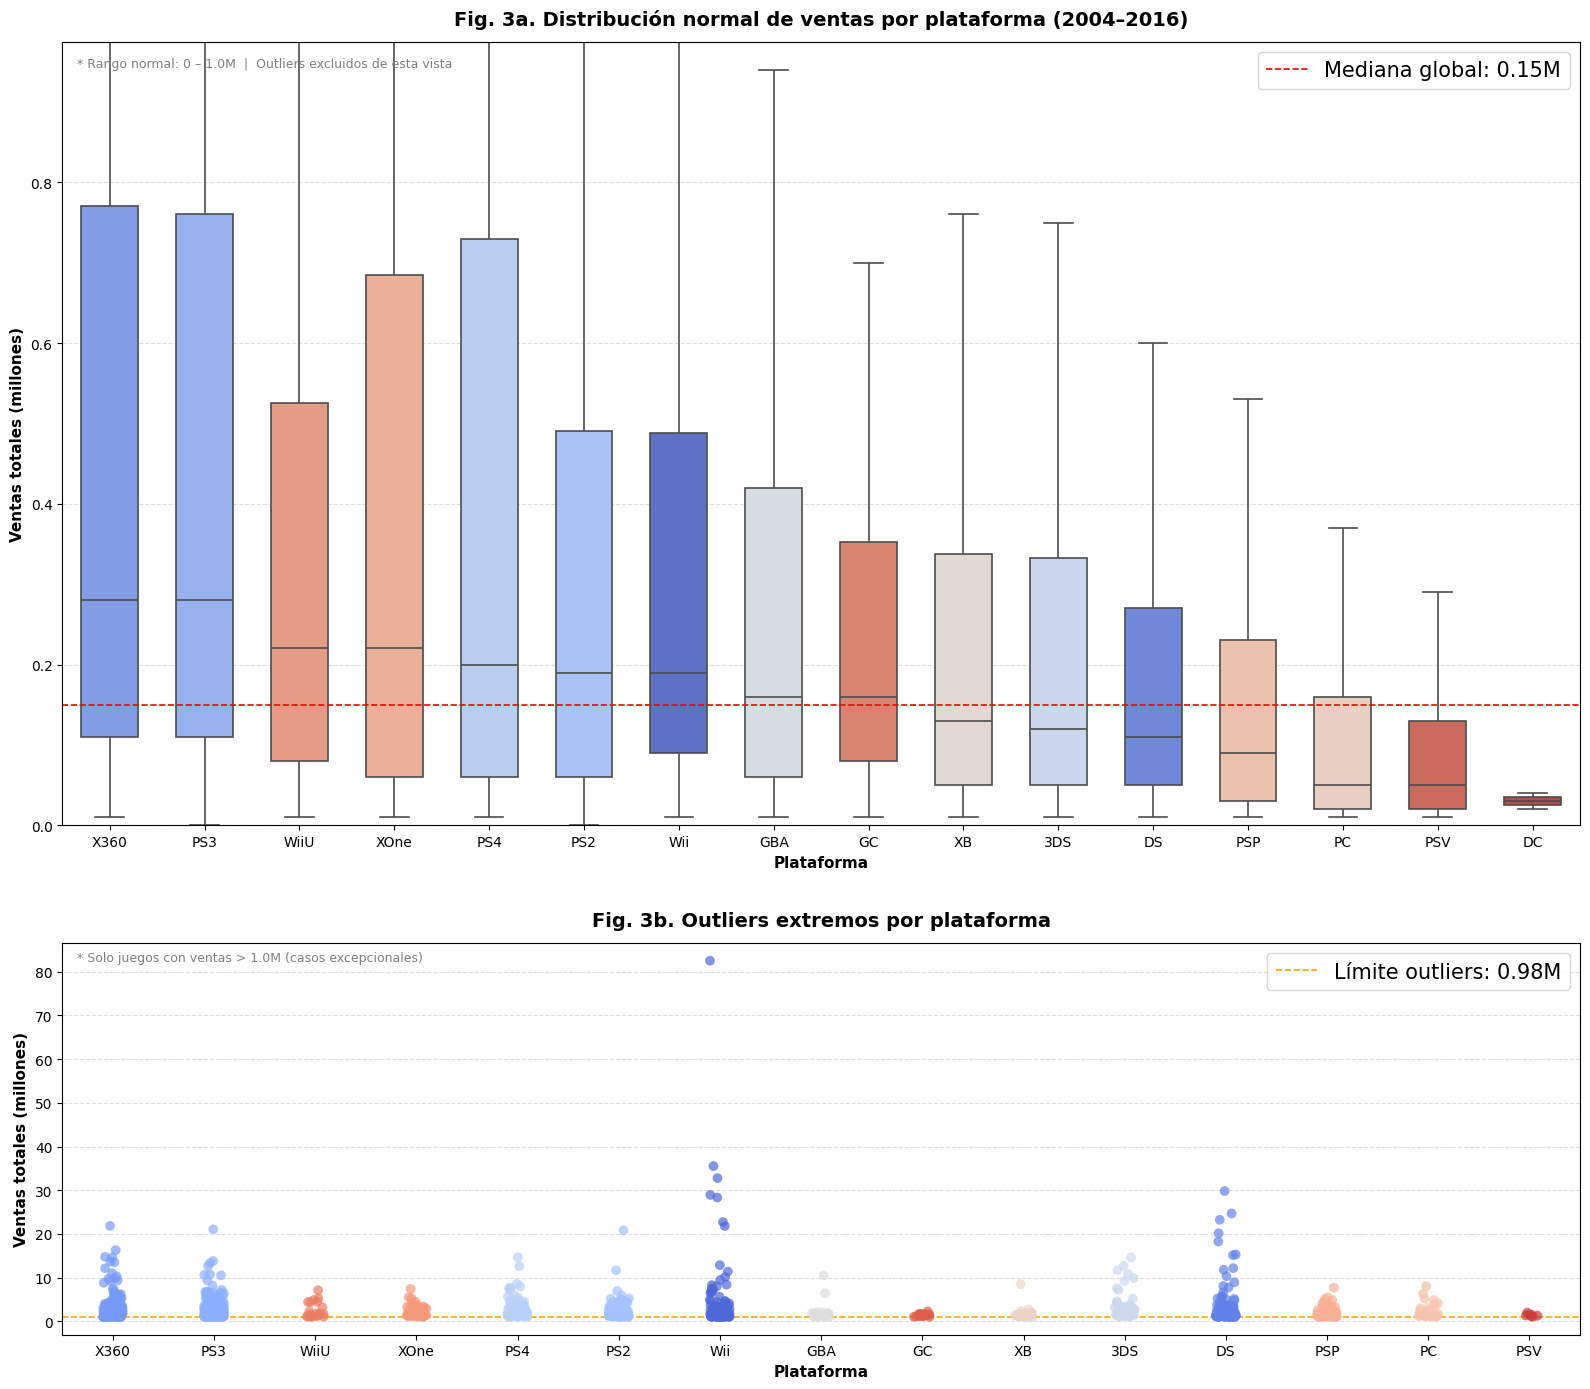

In [19]:
# 1. DATOS BASE 

relevant_data = df_games[
    (df_games['year_of_release'] >= 2004) &
    (df_games['year_of_release'] <= 2016)
]

# 2. ORDEN POR MEDIANA 

order = (relevant_data.groupby('platform')['total_sale']
         .median()
         .sort_values(ascending=False)
         .index)

# 3. PALETA Y MÉTRICAS 

palette        = sns.color_palette('coolwarm', n_colors=len(order))
mediana_global = relevant_data['total_sale'].median()

# 4. CÁLCULO DE OUTLIERS 

Q3      = relevant_data['total_sale'].quantile(0.75)
Q1      = relevant_data['total_sale'].quantile(0.25)
IQR     = Q3 - Q1
limite  = Q3 + 1.5 * IQR
outliers = relevant_data[relevant_data['total_sale'] > limite]

order_outliers   = [p for p in order if p in outliers['platform'].values]
palette_outliers = sns.color_palette('coolwarm', n_colors=len(order_outliers))

print(f"Mediana global : {mediana_global:.2f}M")
print(f"Límite outliers: {limite:.2f}M")
print(f"Total outliers : {len(outliers)} juegos")

# 5. FIGURA CAJA

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14),  # aquí puedes seleccionar la posición de la imagen arriba/abajo (2,1) y izquierda/derecha (1,2)
                                gridspec_kw={'height_ratios': [2, 1]})

# 6. GRÁFICA SUPERIOR: distribución normal

sns.boxplot(
    data      = relevant_data,
    x         = 'platform',
    y         = 'total_sale',
    hue       = 'platform',   # ← agregar esto
    legend    = False,         # ← agregar esto
    order     = order,
    palette   = palette,
    width     = 0.6,
    linewidth = 1.2,
    showfliers= False,
    ax        = ax1
)
ax1.set_ylim(0, limite)
ax1.axhline(y=mediana_global, color='red', linestyle='--',
            linewidth=1.2, label=f'Mediana global: {mediana_global:.2f}M')
ax1.set_title('Fig. 3a. Distribución normal de ventas por plataforma (2004–2016)',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Plataforma', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ventas totales (millones)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=15, loc='upper right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.text(0.01, 0.98,
         f'* Rango normal: 0 – {limite:.1f}M  |  Outliers excluidos de esta vista',
         transform=ax1.transAxes, fontsize=9, color='gray', va='top')

# 7. GRÁFICA INFERIOR: outliers
sns.stripplot(
    data      = outliers,
    x         = 'platform',
    y         = 'total_sale',
    hue       = 'platform',   # ← agregar esto
    legend    = False,         # ← agregar esto
    order     = order_outliers,
    palette   = palette_outliers,
    size      = 7,
    jitter    = True,
    alpha     = 0.7,
    ax        = ax2
)
ax2.axhline(y=limite, color='orange', linestyle='--',
            linewidth=1.2, label=f'Límite outliers: {limite:.2f}M')
ax2.set_title('Fig. 3b. Outliers extremos por plataforma',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Plataforma', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ventas totales (millones)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=15, loc='upper right')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.text(0.01, 0.98,
         f'* Solo juegos con ventas > {limite:.1f}M (casos excepcionales)',
         transform=ax2.transAxes, fontsize=9, color='gray', va='top')

plt.xticks(fontsize=10)
plt.tight_layout(h_pad=3)
plt.show()

### Descripción de las gráficas: "Distribución normal de ventas por plataforma (2004–2016)" y "Outliers extremos por plataforma".

**ESTRUCTURA DEL GRAFICO**

* Eje X (horizontal): Plataformas ordenadas de mayor a menor mediana de ventas.
* Eje Y (vertical): Ventas totales en millones por juego individual.
* Línea roja punteada: Mediana global de todas las plataformas 0.15 millones.
* Las cajas representan: mínimo, Q1, Q2 (mediana), Q3 y máximo de ventas por juego.
* La figura 3b indica los outliers fuertes de Wii y DS estos fueron las plataformas con los juegos más populares del período, seguidos las plataformas X360, PS3 Y PS2 tuvieron más éxitos consistentes aunque menos espectaculares individualmente. Por último las plataformas PSV, GC y XB; muestran outliers débiles en las dos gráficas, confirmando su posición marginal en el mercado.

   
**ANALISIS ESTADISTICO**

**1. Plataformas por encima de la mediana global (0.15 millones)**

Las plataformas más rentables que superan la línea roja son: X360, PS3, WiiU, XOne, PS4, PS2, Wii, GBA y GC; esto indica que juegos vendieron más en promedio que el resto de consolas.

**2. Dispersión de las cajas, tamaño del IQR**

Las cajas más grandes indican mayor variabilidad en ventas, es decir existen juegos muy exitosos y otros poco vendidos en las mismas plataformas. Por otro lado las cajas pequeñas indican ventas más consistentes y predecibles entre sus juegos.

**3. Posición de la mediana dentro de las cajas** 

Las líneas de la mediana están cerca del borde inferior de las cajas, indican la desigualdad en el mercado de los videojuegos (distribución sesgada), la gran mayoría venden cantidades modestas, mientras que otros juegos populares concentran la mayor parte de las ventas y distorsionan la distribución hacia arriba.  

**4. Plataformas con bigotes largos**

Los bigotes largos hacia arriba como las plataformas X36O, PS3, PS2, Wii y DS; indican que tienen juegos con ventas muy superiores al resto de su catálogo, es decir éxitos puntuales pero no consistentes.

**5. Plataformas con ventas más consistentes**

PSV y DC, muestran cajas muy pequeñas y compactas, indican poca variabilidad, sus juegos fueron vendidos en volúmenes bajos.



##  Diferencias significativas en las ventas

En las gráficas 3a y 3b confirma que si existen diferencias muy significativas entre plataformas, tanto en el volumen típico de ventas como en la capacidad de generar juegos exitosos.


**1. Plataformas de alto rendimiento:**

Las plataformas de 7ª generación lideran las ventas por juego individual, por encima de la media global de 0.15 millones:

* X360 y PS3 con medianas de ~0.27 millones las más altas del dataset, con cajas grandes que indican alta variabilidad, es decir además de vender bien en promedio, tuvieron videojuegos muy exitosos que elevaron significativamente la distribución.

* WiiU y XOne con medianas de ~0.23 millones, por encima de la media global, pero con menos outliers extremos (fig.3b), lo que indica que tuvo un rendimiento sólido pero sin juegos exitosos como las plataformas X360 o PS3.


**2. Plataformas de bajo rendimiento:**

* PSV y DC con medianas ~0.05 millones, muy por debajo de la media global, con cajas muy pequeñas que indican ventas consistentemente bajas en sus catálogo. La fig. 3b muestra los outliers mínimos, por lo que indican que los mejores juegos no lograron ventas masivas.


**3. Desigualdad extrema del mercado**

* La mediana global se encuentra cerca del borde inferior de las cajas, confirmando una distribución fuertemente sesgada. Esto significa que la mayoría de videojuegos venden cantidades modestas mientras que unos pocos videojuegos exitosos o populares concentran la mayor parte de las ventas, este patrón estructural es mu común en la industria de los videojuegos.

**4. Variabilidad por plataforma**

* **Alta variabilidad:** Las plataformas X360, PS3, PS4 presentan las cajas más grandes en dónde algunos juegos son muy exitosos.

* **Baja variabilidad:** PSV y DC muestran cajas muy pequeñas en dónde las ventas son consistentemente bajas.

**5. Outliers revelan éxitos excepcionales**

* Las plataformas Wii y DS tienen los outliers más extremos con juegos superando los 20 millones de ventas, los más altos de todo el período, sin embargo en la fig. 3a son cajas medianas, lo que significa que el éxito en sus ventas dependió de unos pocos juegos masivos.

* X360 y PS3 son cajas altas pero con nubes densas de outliers, siendo las plataformas más equilibradas con un rendimiento general alto y múltiples juegos exitosos simultáneamente.

### GRAFICA DE DISPERSION: RESEÑAS EN VENTAS

Juegos de PS3: 1306
--------------------------------------------------
Plataforma disponibles: ['Wii' 'DS' 'X360' 'PS3' 'PS2' 'PS4' '3DS' 'GBA' 'XB' 'PC' 'PSP' 'XOne'
 'WiiU' 'GC' 'PSV' 'DC']


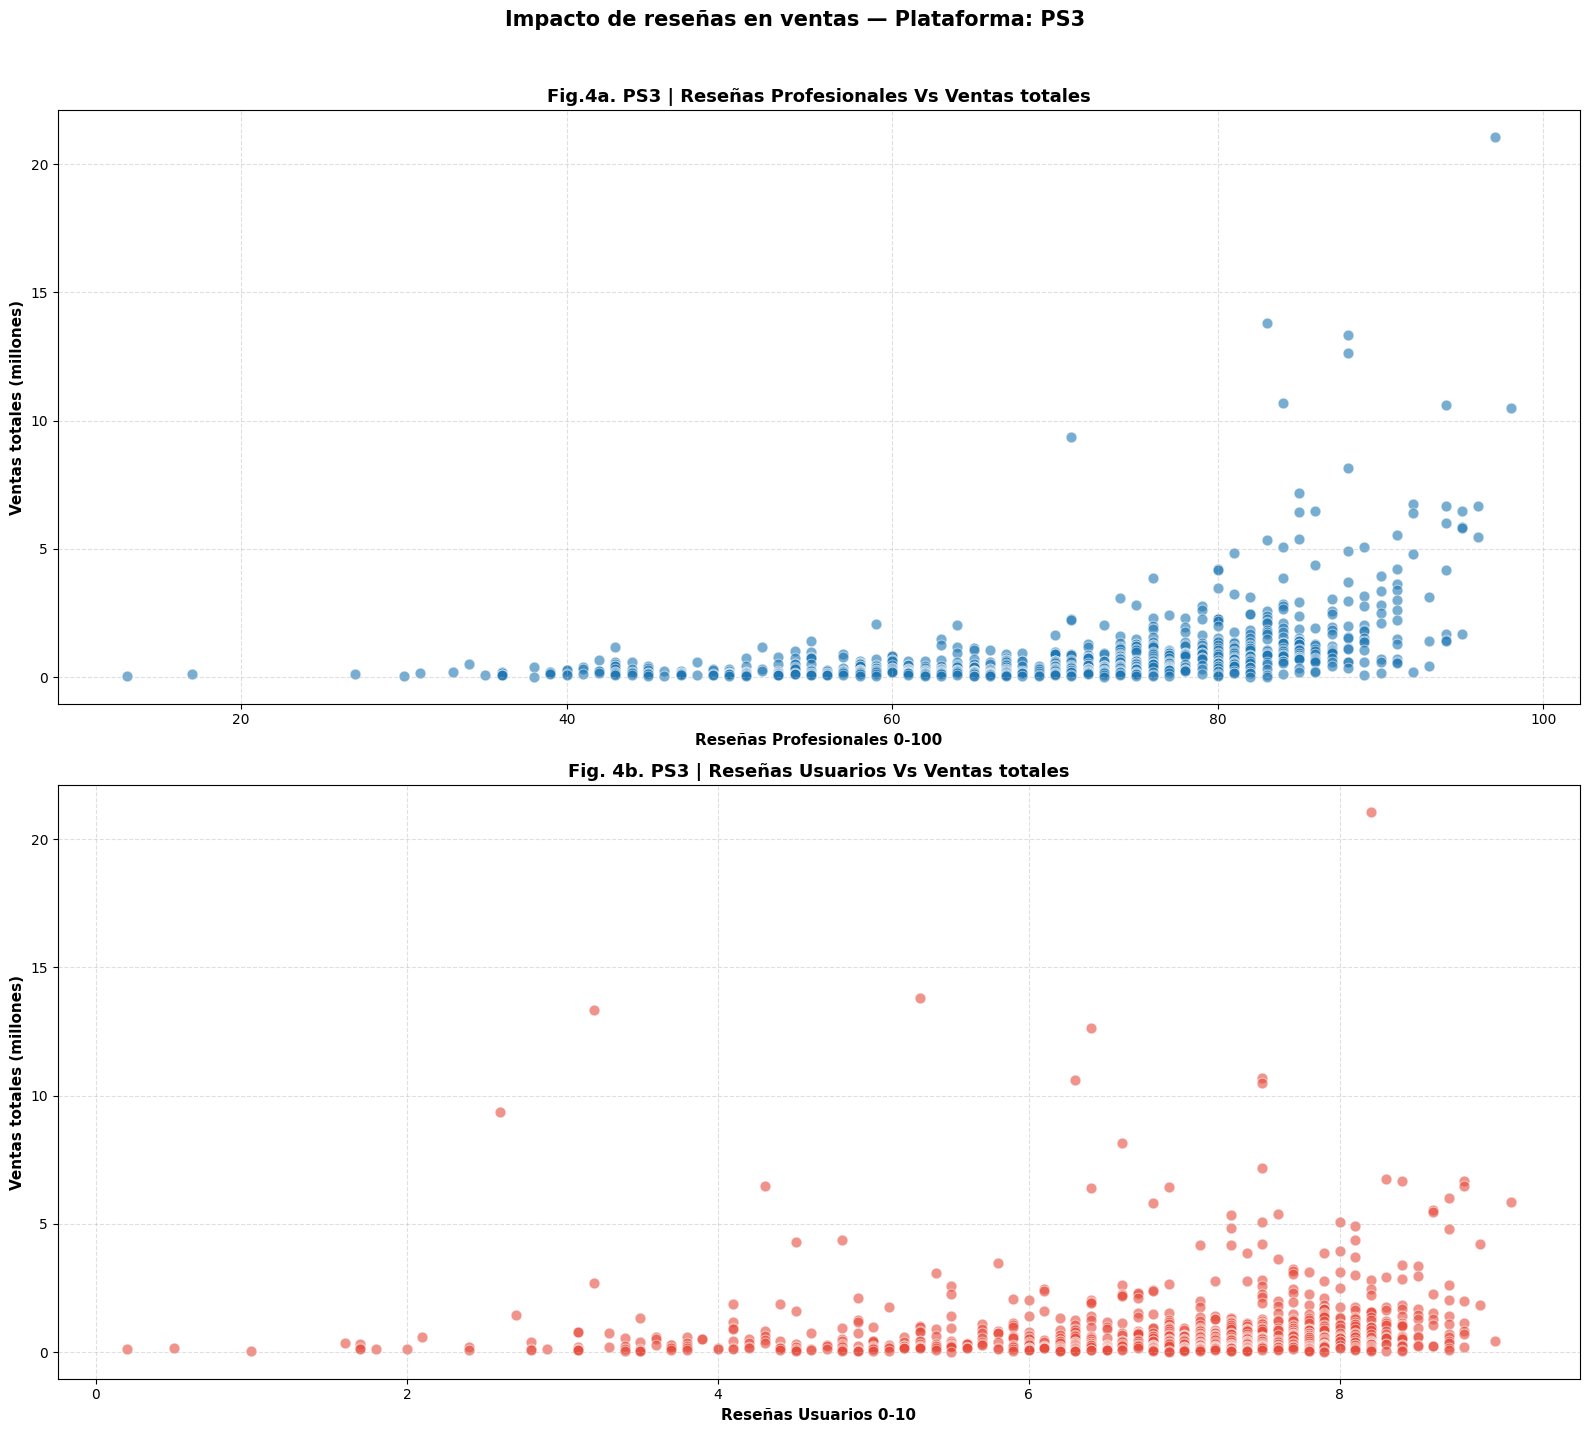

In [20]:
#Seleccionar plataforma

plataforma_elegida = "PS3"

df_platform = relevant_data[relevant_data['platform'] == plataforma_elegida]


print(f"Juegos de {plataforma_elegida}: {len(df_platform)}")
print("-" * 50)
print(f"Plataforma disponibles: {relevant_data['platform'].unique()}")

# Gráfica de dispersión 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))  

# Reseña de profesionales

sns.scatterplot(
    data = df_platform,
    x = "critic_score",
    y = "total_sale",
    alpha = 0.6,
    s = 60,                 # ← tamaño de los puntos
    ax = ax1
)

ax1.set_title(f"Fig.4a. {plataforma_elegida} | Reseñas Profesionales Vs Ventas totales",
             fontsize=13, fontweight='bold')
ax1.set_xlabel("Reseñas Profesionales 0-100", fontsize=11, fontweight='bold')
ax1.set_ylabel("Ventas totales (millones)", fontsize=11, fontweight='bold')
ax1.grid(linestyle='--', alpha=0.4)


#Reseña de usuarios

sns.scatterplot(
    data = df_platform,
    x = "only_user_score",
    y = "total_sale",
    color = '#e74c3c',
    alpha = 0.6,
    s = 60,
    ax = ax2
)

ax2.set_title(f"Fig. 4b. {plataforma_elegida} | Reseñas Usuarios Vs Ventas totales",
             fontsize=13, fontweight='bold')
ax2.set_xlabel("Reseñas Usuarios 0-10", fontsize=11, fontweight='bold')
ax2.set_ylabel("Ventas totales (millones)", fontsize=11, fontweight='bold')
ax2.grid(linestyle='--', alpha=0.4)

plt.suptitle(f'Impacto de reseñas en ventas — Plataforma: {plataforma_elegida}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Coeficiente de Pearson

In [21]:
from scipy.stats import pearsonr

# Limpiar NaN para el cálculo 
critic_clean = df_platform[['critic_score', 'total_sale']].dropna()
user_clean   = df_platform[['only_user_score',   'total_sale']].dropna()

# Calcular correlación con p-value
corr_critic, p_critic = pearsonr(critic_clean['critic_score'], critic_clean['total_sale'])
corr_user,   p_user   = pearsonr(user_clean['only_user_score'], user_clean['total_sale'])

# Función para interpretar la correlación 
def interpretar_corr(r):
    if   abs(r) >= 0.7: return 'Correlación FUERTE'
    elif abs(r) >= 0.4: return 'Correlación MODERADA'
    elif abs(r) >= 0.2: return 'Correlación DÉBIL'
    else:               return 'Sin correlación'

def interpretar_p(p):
    if   p < 0.001: return 'Muy significativo (p<0.001)'
    elif p < 0.01:  return 'Significativo (p<0.01)'
    elif p < 0.05:  return 'Significativo (p<0.05)'
    else:           return 'No significativo (p>0.05)'

# Resultados 

print(f'   CORRELACIÓN DE PEARSON — Plataforma: {plataforma_elegida}')
print('-' * 50)
print(f"Juegos usados critic_score: {len(critic_clean)}")
print(f"Juegos usados only_user_score: {len(user_clean)}")
print('-' * 50)
print(f"Critic Score r = {corr_critic:.3f} | p = {p_critic:.4f}")
print(f"  {interpretar_corr(corr_critic)} | {interpretar_p(p_critic)}")
print('-' * 50)
print(f"User Score r = {corr_user:.3f} | p = {p_user:.4f}")
print(f"  {interpretar_corr(corr_user)} | {interpretar_p(p_user)}")
print('-' * 50)


   CORRELACIÓN DE PEARSON — Plataforma: PS3
--------------------------------------------------
Juegos usados critic_score: 804
Juegos usados only_user_score: 861
--------------------------------------------------
Critic Score r = 0.433 | p = 0.0000
  Correlación MODERADA | Muy significativo (p<0.001)
--------------------------------------------------
User Score r = 0.128 | p = 0.0002
  Sin correlación | Muy significativo (p<0.001)
--------------------------------------------------


### Descripción de las gráficas: "Impacto de reseñas en ventas — Plataforma PS3"

**ESTRUCTURA DE LOS GRAFICOS**

* Eje X (horizontal): Reseñas de los profesionales y usuarios.
* Eje Y (vertical): Ventas totales en millones de la consola PS3.

### Análisis estadístico de 'PEARSON'

Las dos variables (r) indican comportamientos distintos:

**Critic Score (r = 0.433):** Presenta una correlación MODERADA(fig. 4a), los puntos muestran una tendencia ascendente clara hacia la derecha, no es una correlación perfecta pero si observable, indicando que a mayor puntuación de los críticos, mayor probabilidad de ventas altas pero no garantiza ventas altas.

**User Score (r = 0.128):** No presenta correlación (fig. 4b), confirmando que la opinión de los usuarios no tienen relación con la venta de juegos en PS3. Los puntos se encuentran dispersos sin ninguna tendencia definida, indica que un criterio 9 puede vender igual que un criterio de puntuación 5.

Los dos resultados son estadísticamente significativos por que p-value es menor a 0.05 en los dos casos.

* **Critic Score** es significativo y con una correlación MODERADA (r=0.433) dando un resultado confiable y útil.

* **User Score** es significativo pero con SIN correlación (r=0.128), por lo tanto no es útil para tomar decisiones.


#### Recomendaciones concretas en base a los criterios profesionales y usuarios.

  1. **Priorizar critic_score** la tienda debería usar a los criterios profesionales como uno de los filtros principales como punto de partida para el criterio de compra de inventario, debido que los juegos de PS3 con puntuaciones mayores a 80 tienen mayor probabilidad de vender bien.
 
  2. **Critic_score no garantizaría** algún éxito, la correlación es MODERADA y no fuerte, en la gráfica se observa juegos con score 90+ vendieron poco y juegos con score 70 que vendieron mucho. Esto indicaría que se debe tomar en consideración otros factores adicionales como: franquicias, marketing o la exclusividad de un buen título.
 
  3. **No usar user_score** como un criterio de decisión de inventario, ya que la correlación es de 0.128 por lo tanto, indica que la opinión de los usuarios no predicen ventas en PS3.

### Comparación de los juegos de PS3 con otras plataformas

   Juegos Mutiplataforma con PS3
--------------------------------------------------
Juegos solo en PS3                : 280
Juegos en PS3 + otras plataformas : 1025
Total de juegos de PS3            : 1305 

Ventas promedio por plataforma (mismos juegos)
          promedio  mediana  total_ventas  juegos
platform                                         
PS4           1.04     0.34        184.48     178
X360          0.87     0.39        715.99     819
PS3           0.76     0.33        777.01    1026
XOne          0.74     0.32         83.80     113
PS2           0.67     0.39        115.06     172
Wii           0.66     0.36        182.52     275
DS            0.47     0.25         63.65     136
PSP           0.37     0.25         56.58     151
XB            0.30     0.18          3.91      13
3DS           0.27     0.18         18.23      68
PC            0.27     0.08         79.20     293
WiiU          0.26     0.19         18.25      69
GC            0.23     0.11          1.87    

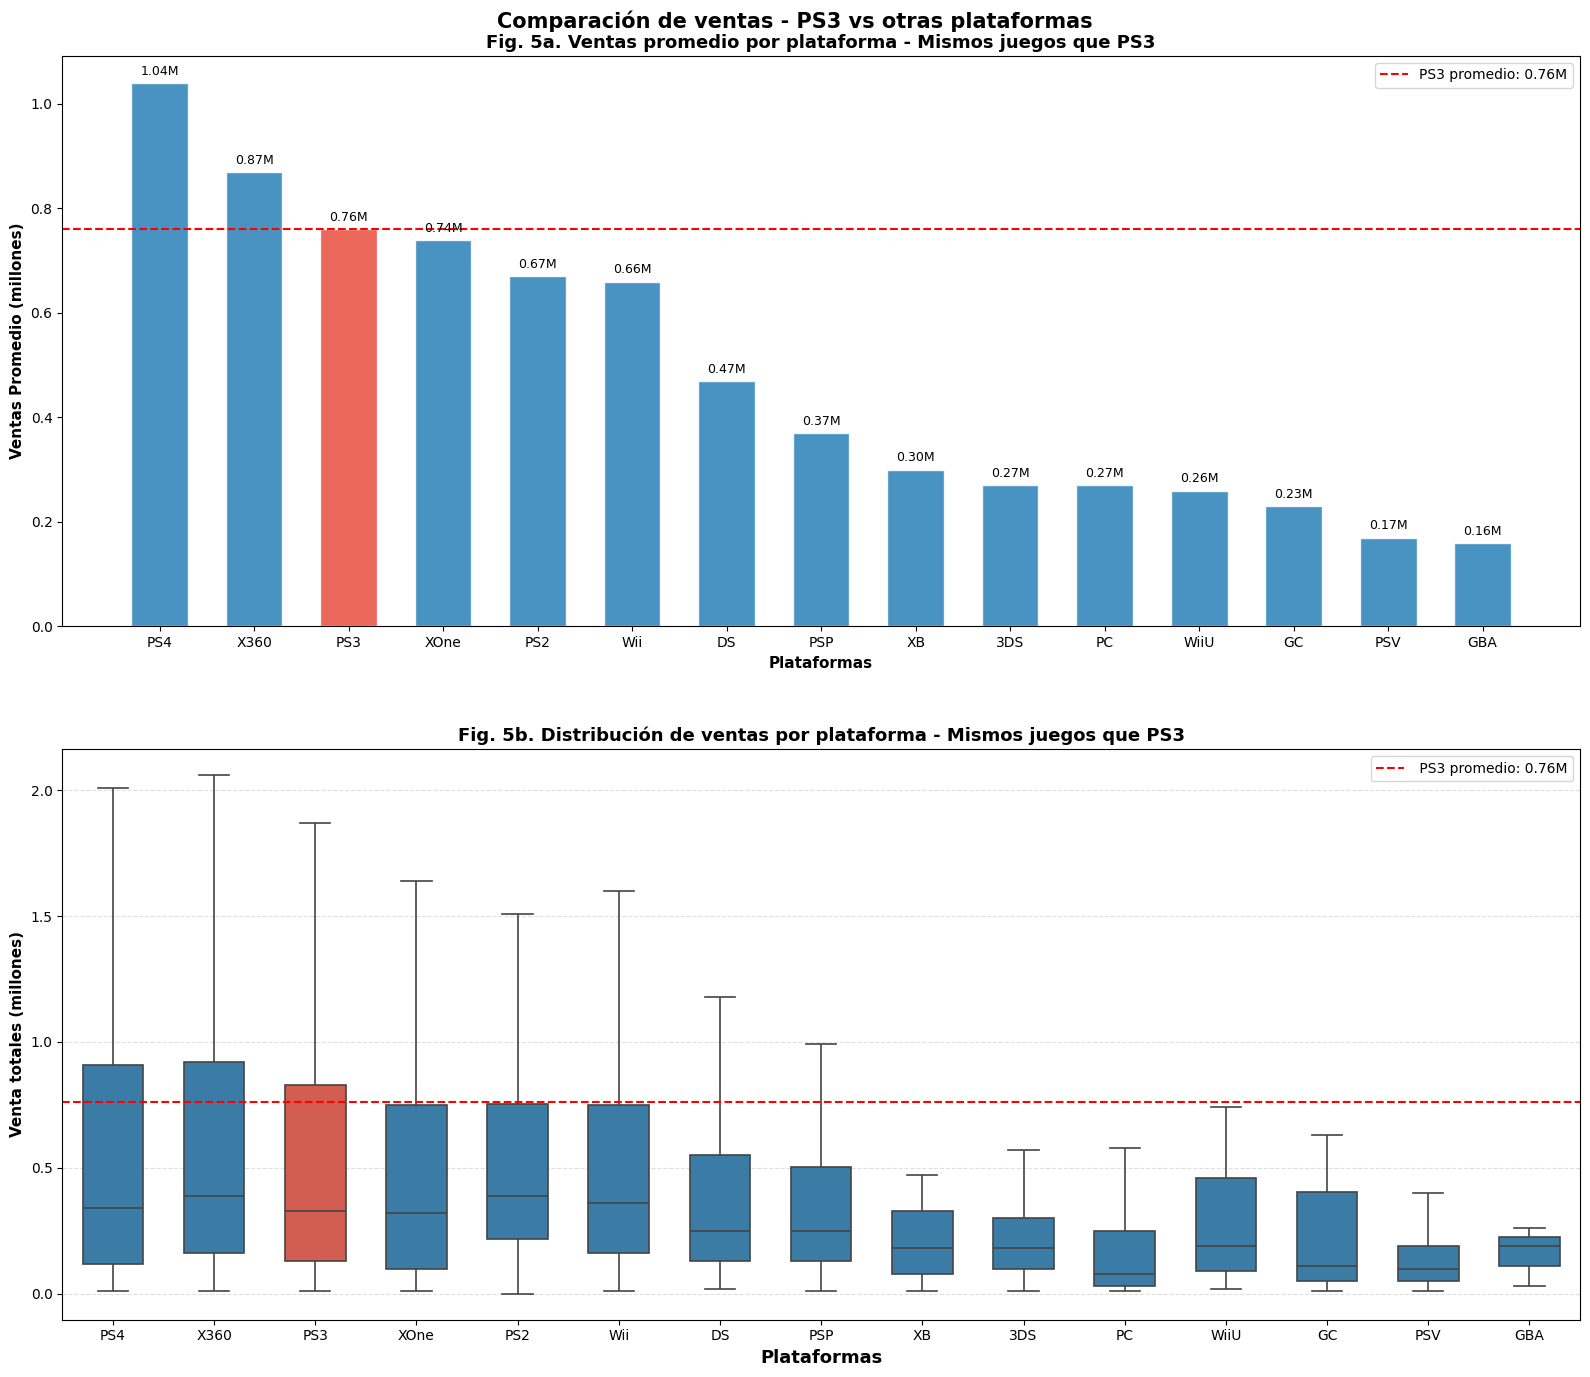

In [22]:
# 1. Juegos que están en PS3 y en otras plataformas

juegos_con_ps3 = relevant_data.groupby('name')['platform'].apply(list)
juegos_ps3_multi = juegos_con_ps3[juegos_con_ps3.apply(lambda x: 'PS3'  in x and len(x) > 1)]

solo_ps3 = juegos_con_ps3.apply(lambda x: x == ['PS3']).sum()
ps3_multi = len(juegos_ps3_multi)
total_ps3 = solo_ps3 + ps3_multi

print(f"   Juegos Mutiplataforma con {plataforma_elegida}")
print('-' * 50)
print(f"Juegos solo en {plataforma_elegida}                : {solo_ps3}")
print(f"Juegos en {plataforma_elegida} + otras plataformas : {ps3_multi}")
print(f"Total de juegos de {plataforma_elegida}            : {total_ps3} ")

# 2. Filtrar el dataset con juegos multiplataforma

df_ps3_comparison = relevant_data[relevant_data['name'].isin(juegos_ps3_multi.index)]

# 3. Ventas promedio por plataforma

ventas_por_plataforma = (df_ps3_comparison
                        .groupby('platform')['total_sale']
                        .agg(['mean', 'median', 'sum', 'count'])
                        .round(2)
                        .sort_values('mean', ascending=False))

ventas_por_plataforma.columns = ['promedio', 'mediana', 'total_ventas', 'juegos']

print("\nVentas promedio por plataforma (mismos juegos)")
print(ventas_por_plataforma)
print("=" * 50)

# 4. Orden y paleta

order_comp = ventas_por_plataforma.index.tolist()

# Lista para matplotlib (ax1.bar)
palette_list = ['#e74c3c' if p == plataforma_elegida else '#2980b9' for p in order_comp]  # PS3 en rojo y el resto de plataformas en azul

# Diccionario para seaborn (sns.boxplot)
palette_dict = {p: '#e74c3c' if p == plataforma_elegida else '#2980b9' for p in order_comp}  # PS3 en rojo y el resto de plataformas en azul


# 5. Gráfica

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# Gráfica 5a: Promedio de ventas por plataforma

bars = ax1.bar(order_comp,
             ventas_por_plataforma['promedio'],
             color = palette_list,
             alpha = 0.85,
             width = 0.6,
             edgecolor = 'white')

# Etiqueta de valor encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            f'{height:.2f}M', ha='center', va='bottom', fontsize=9)

# Línea de referencia de PS3

ps3_promedio = ventas_por_plataforma.loc['PS3', 'promedio']
ax1.axhline(y=ps3_promedio, color='red', linestyle='--',
           linewidth=1.5, label=f'{plataforma_elegida} promedio: {ps3_promedio:.2f}M')

ax1.set_title(f"Fig. 5a. Ventas promedio por plataforma - Mismos juegos que PS3",
              fontsize=13, fontweight='bold')

ax1.set_xlabel('Plataformas', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ventas Promedio (millones)', fontsize=11, fontweight='bold')
ax1.set_axisbelow(True)
ax1.legend(fontsize=10)

# Gráfico 5b Boxplot comparativo

sns.boxplot(
    data = df_ps3_comparison,
    x = 'platform',
    y = 'total_sale',
    hue = 'platform',
    order = order_comp,
    palette = palette_dict,
    legend = False,
    showfliers = False,
    width = 0.6,
    linewidth = 1.2,
    ax = ax2
)

ax2.axhline(y=ps3_promedio, color='red', linestyle='--',
           linewidth= 1.5, label=f" {plataforma_elegida} promedio: {ps3_promedio:.2f}M")
ax2.set_title(f"Fig. 5b. Distribución de ventas por plataforma - Mismos juegos que {plataforma_elegida}", 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Plataformas', fontsize=13, fontweight='bold')
ax2.set_ylabel('Venta totales (millones)', fontsize=11, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.legend(fontsize=10)

plt.suptitle(f"Comparación de ventas - {plataforma_elegida} vs otras plataformas", 
            fontsize=15, fontweight='bold')


plt.tight_layout(h_pad=4) # Espacio entre imágenes
plt.show()
              

### Descripción de las gráficas: "Comparación de ventas - PS3 vs otras plataformas"

**ESTRUCTURA DE LOS GRAFICOS**

* Eje X (horizontal): Nombres de plataformas.
* Eje Y (vertical): Ventas totales en millones de cada plataformas

### Análisis estadístico

* Aunque PS3 lidera en volumen total con 777M en 1026 juegos, PS4 es la plataforma más rentable y eficiente comercialmente con un promedio de 1.04 M por juego, lo que indica que es la plataforma más eficiente comercialmente.

* X360 es el competidor más directo de PS3 con 0.87M de promedio, siendo una rivalidad algo equilibrada y prolongada del periodo.

* En la figura 5b se observa que todas las medianas están cercar del borde inferior de cada caja y por debajo del promedio de PS3, confirmando que la distribución está sesgada en todo el mercado, y que la mayoría de juegos venden entre 0.1M y 0.4M y son pocos los juegos exitosos que elevan el promedio hacia arriba. 

* Las plataformas en declive están GBA con 3 juegos comparables y 0.16M de promedio, GC con 8 juegos y 0.23M, y XB con 13 juegos y 0.30M confirman visualmente su salida del mercado durante el período analizado.

* Los mismos juegos de PS3 venden significativamente más en PS4 que en cualquier otra plataforma, por lo tanto se recomienda  direccionar el enfoque a inventarios en la plataforma PS4, como plataforma prioritaria para 2017 complementada con X360  ya que los mismo juegos demuestran mayor rentabilidad en estas dos plataformas.




### GENEROS DE VIDEOJUEGOS

In [23]:
# Agrupar juegos del periodo 2004-2016 por género

genre_analys = (relevant_data.groupby('genre')['total_sale']
                .agg(['mean', 'median', 'sum', 'count'])
                .round(2)
                .sort_values('mean', ascending=False ))

genre_analys.columns = ['promedio', 'mediana', 'total_ventas', 'total_juegos']

print('\nVentas Promedio por GENERO')
print(genre_analys)


Ventas Promedio por GENERO
              promedio  mediana  total_ventas  total_juegos
genre                                                      
Shooter           0.87     0.26        805.50           921
Platform          0.72     0.21        350.28           489
Sports            0.62     0.21        916.95          1489
Racing            0.57     0.17        402.90           709
Role-Playing      0.54     0.15        604.74          1127
Action            0.47     0.17       1278.17          2699
Fighting          0.45     0.17        224.83           495
Misc              0.45     0.14        646.99          1453
Simulation        0.42     0.13        280.49           671
Puzzle            0.28     0.09        118.68           424
Strategy          0.19     0.08         85.56           454
Adventure         0.14     0.04        158.43          1103


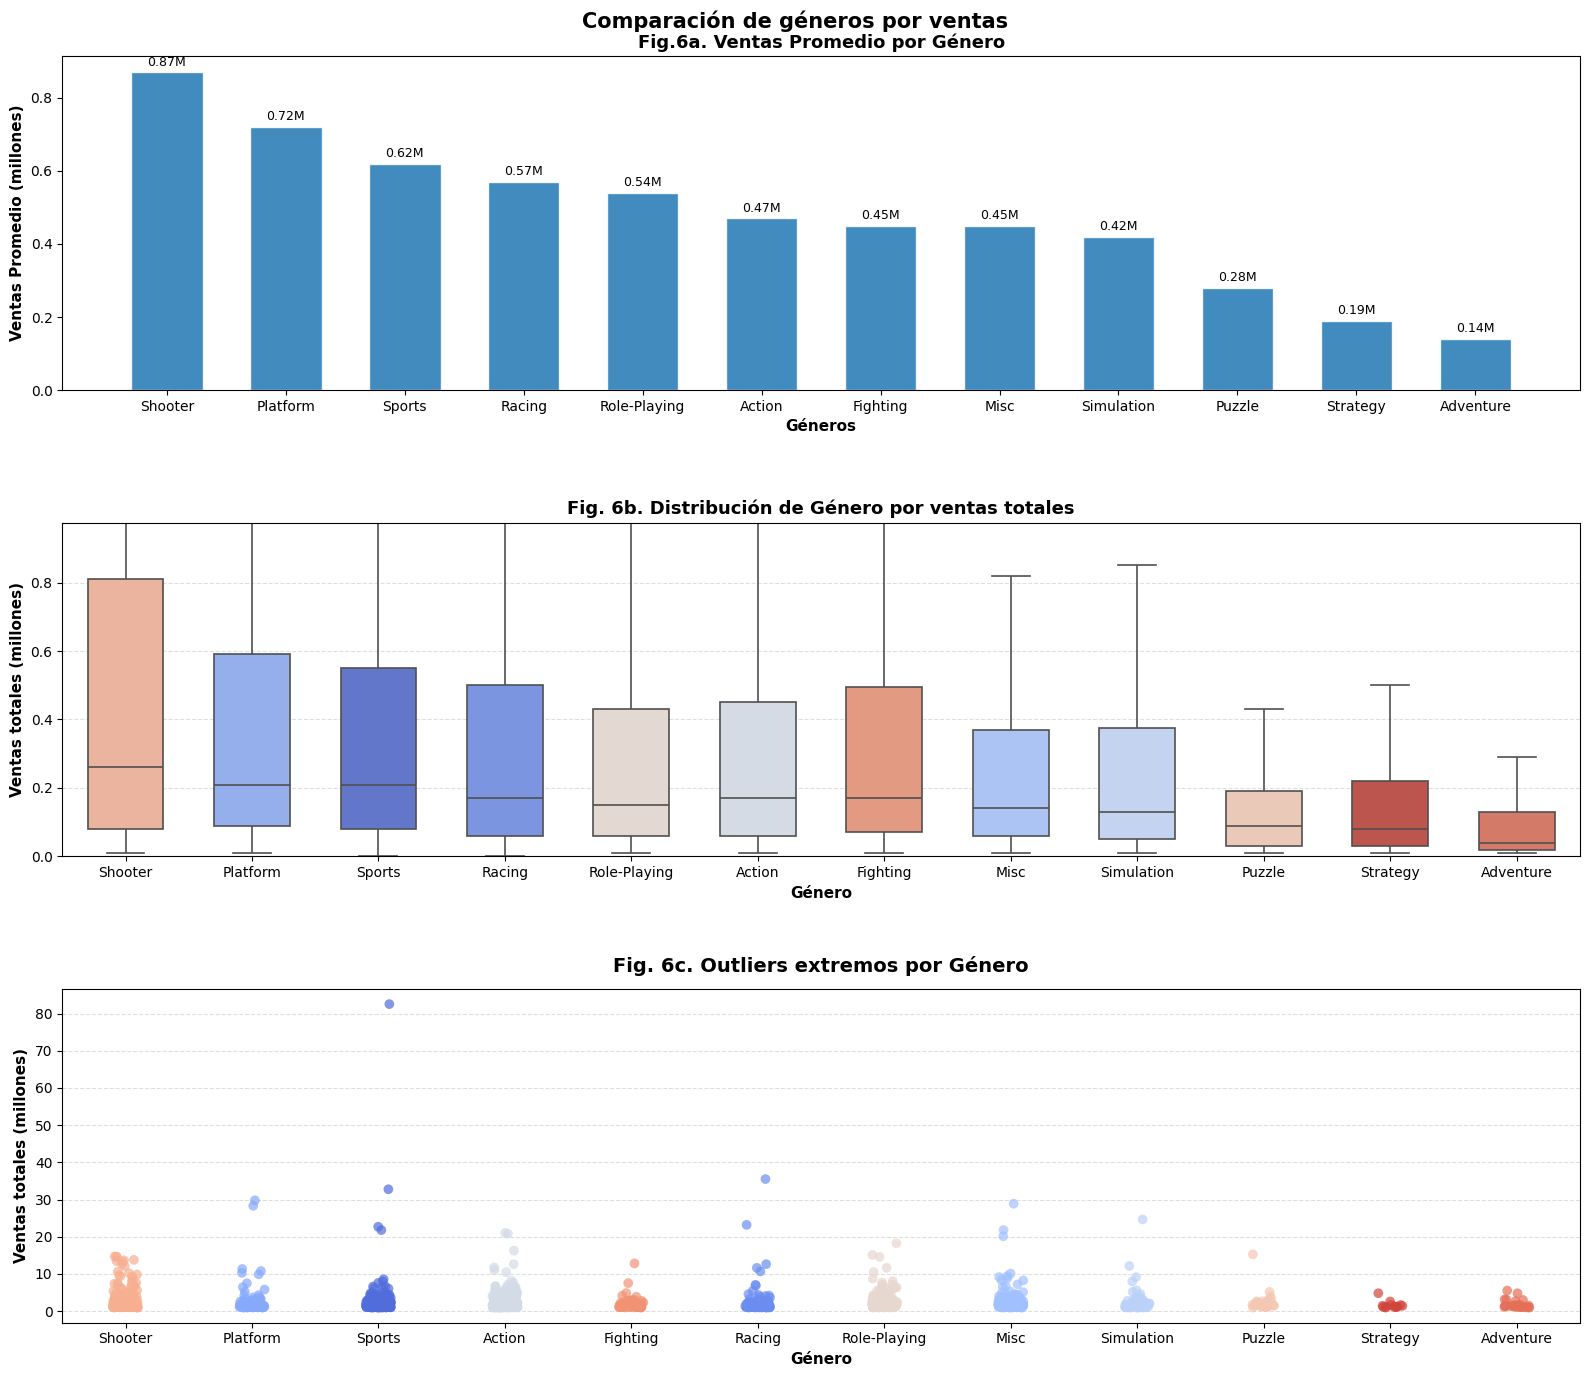

In [24]:
# Gráfico 6a. de barras ventas totales por género


order_genre = genre_analys.index.tolist()
palette_genre = sns.color_palette('coolwarm', n_colors=len(order_genre))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14))

bars = ax1.bar(order_genre,
              genre_analys['promedio'],
              alpha = 0.85,
              width = 0.6,
              edgecolor = 'white')

# Etiqueta de valor encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            f'{height:.2f}M', ha= 'center', va= 'bottom', fontsize=9)

ax1.set_title(f'Fig.6a. Ventas Promedio por Género',
             fontsize=13, fontweight='bold')
ax1.set_xlabel('Géneros', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ventas Promedio (millones)', fontsize=11, fontweight='bold')
ax1.set_axisbelow(True) # Coloca cuadrículas detas de las barras

# Gráfico 6b. Boxplot comparativo

sns.boxplot(
    data = relevant_data,
    x = 'genre',
    y = 'total_sale',
    hue = 'genre',
    legend = False,
    order = order_genre,
    palette = palette_genre,
    width = 0.6,
    linewidth = 1.2,
    showfliers= False,
    ax = ax2
    
)

ax2.set_ylim(0, limite)
ax2.set_title(f'Fig. 6b. Distribución de Género por ventas totales',
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Género', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ventas totales (millones)', fontsize=11, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)  # Coloca cuadrículas detrás de las barras

plt.suptitle(f"Comparación de géneros por ventas", 
            fontsize=15, fontweight='bold')

# Cálculo de outliers
 
order_genre = (relevant_data.groupby('genre')['total_sale']
         .median()
         .sort_values(ascending=False)
         .index)

order_genre_outliers   = [p for p in order_genre if p in outliers['genre'].values]
palette_genre_outliers = sns.color_palette('coolwarm', n_colors=len(order_genre_outliers))

sns.stripplot(
    data = outliers,
    x = 'genre',
    y = 'total_sale',
    hue = 'genre',
    legend = False,
    order = order_genre_outliers,
    palette = palette_genre_outliers,
    size = 7,
    jitter = True,
    alpha = 0.7,
    ax =ax3    
)

ax3.set_title('Fig. 6c. Outliers extremos por Género',fontsize = 14, fontweight= 'bold', pad=12)
ax3.set_xlabel('Género', fontsize=11, fontweight='bold')
ax3.set_ylabel('Ventas totales (millones)', fontsize=11, fontweight='bold')
ax3.grid(axis= 'y', linestyle= '--', alpha=0.4)
ax3.set_axisbelow(True)  # Coloca cuadrículas detrás de las barras


plt.xticks(fontsize=10)

plt.tight_layout(h_pad=4) # Espacio entre imágenes
plt.show()

### Descripción de las gráficas: "Comparación de Géneros por ventas"

**ESTRUCTURA DE LOS GRAFICOS**

* Eje X (horizontal): Nombres de Géneros.
* Eje Y (vertical): Ventas totales en millones de cada genero.

### Análisis estadístico

Para el análisis del periodo 2004-2016, los géneros se dividen en tres categorías:

#### 1. Géneros con **"rentabilidad ALTA"** por juego

   * **Shooter** es el género **más rentable** con un promedio de 0.87M por juego, aunque tiene 921 juegos totales, indica que es el género más eficiente comercialmente; por otro lado, la caja es alta (fig. 6b) pero con nubes densas de outliers, siendo el  más equilibrado con un rendimiento general alto y múltiples juegos exitosos simultáneamente.

   * El segundo género más rentable es **Platform** con un promedio de 0.72M por juego con 489 juegos totales, menor cantidad de juegos pero muy exitoso, la caja es mediana (fig.6b) con una nube densa de outliers que alcanzan ~30 millones.

   * **Sport** es el tercer género mas rentable con 0.62M de promedio por juego, con un gran volumen total de 1489 juegos; además tiene los outliers más extremos con juegos superando los 80 millones de ventas, los más altos de todo el período, sin embargo la caja es mediana (fig.6b) lo que significa que el éxito de sus ventas dependió de pocos juegos masivos.

#### 2. Géneros con **"rentabilidad MEDIA"**
   
   * **Racing, Role-Playing, Action, Fighting, Misc y Simulation;** con un promedio entre 0.42M - 0.57M, sin embargo **Action** tiene un volumen total de 2699 juegos y su rentabilidad es moderada. Por otro lado **Role-Playing** mantiene una base fiel de usuarios.

#### 3. Géneros con **"rentabilidad BAJA"**
 
   * **Puzzle, Strategy y Adventure** con promedio por debajo de los 0.28M, aunque Adventure tiene un volumen total alto con 1103 juegos las ventas individuales son las más bajas.


#### Generalizaciones Importantes

**Géneros con ventas altas:**

* Son géneros accesibles para todo tipo de jugador, sin importar su experiencia. Cuentan con grandes presupuestos de producción y marketing, y suelen lanzar entregas frecuentes con audiencias ya fieles. Ejemplos como acción, deportes y disparos se convirtieron en entretenimiento masivo comparable a películas de taquilla.

**Géneros con ventas bajas:**

* Son géneros dirigidos a un público específico y especializado. Requieren más tiempo y habilidad para aprenderse, lo que limita su audiencia. Aunque venden menos, generan comunidades muy leales y son rentables para desarrolladores pequeños con costos de producción bajos.


 

## Paso 4: Crea un perfil de usuario para cada región

### 4.1. Las  5 plataformas principales por región

In [25]:
# Agrupar por plataforma y sumar ventas por región

regional_analysis = relevant_data.groupby('platform').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum',
    'jp_sales': 'sum'
}).round(2)

# Top 5 de cada región

top5_na = regional_analysis.sort_values('na_sales', ascending=False).head(5)
top5_eu = regional_analysis.sort_values('eu_sales', ascending=False).head(5)
top5_jp = regional_analysis.sort_values('jp_sales', ascending=False).head(5)

# Plataformas  top 5
all_top5_plataform = list(set(
    top5_na.index.tolist() + 
    top5_eu.index.tolist() +
    top5_jp.index.tolist()
))

# Construir DataFrame comparativo
compare_df = regional_analysis.loc[all_top5_plataform][['na_sales', 'eu_sales', 'jp_sales']].sort_values('na_sales', ascending=False)

# Calcular total para los porcentajes por región
total_na = compare_df['na_sales'].sum()
total_eu = compare_df['eu_sales'].sum()
total_jp = compare_df['jp_sales'].sum()

# Porcentajes por región
compare_df['na_pct_%'] = (compare_df['na_sales'] / total_na * 100).round(2)
compare_df['eu_pct_%'] = (compare_df['eu_sales'] / total_eu * 100).round(2)
compare_df['jp_pct_%'] = (compare_df['jp_sales'] / total_jp * 100).round(2)

# Top 5 porcentajes
top5_na = compare_df.sort_values('na_sales', ascending=False).head(5)
top5_eu = compare_df.sort_values('eu_sales', ascending=False).head(5)
top5_jp = compare_df.sort_values('jp_sales', ascending=False).head(5)


print('TOP 5 PLATAFORMAS - NORTEAMERICA:')
print(top5_na[['na_sales', 'na_pct_%']])

print('\nTOP 5 PLATAFORMAS - EUROPA:')
print(top5_eu[['eu_sales', 'eu_pct_%']])

print('\nTOP 5 PLATAFORMAS - JAPON:')
print(top5_jp[['jp_sales', 'jp_pct_%']])
      

TOP 5 PLATAFORMAS - NORTEAMERICA:
          na_sales  na_pct_%
platform                    
X360        595.74     25.46
Wii         486.87     20.80
PS3         390.13     16.67
DS          380.31     16.25
PS2         297.27     12.70

TOP 5 PLATAFORMAS - EUROPA:
          eu_sales  eu_pct_%
platform                    
PS3         327.21     24.93
X360        268.32     20.45
Wii         258.32     19.68
DS          188.41     14.36
PS2         143.15     10.91

TOP 5 PLATAFORMAS - JAPON:
          jp_sales  jp_pct_%
platform                    
DS          175.00     30.09
3DS         100.62     17.30
PS3          79.41     13.65
PSP          75.88     13.05
PS2          70.15     12.06


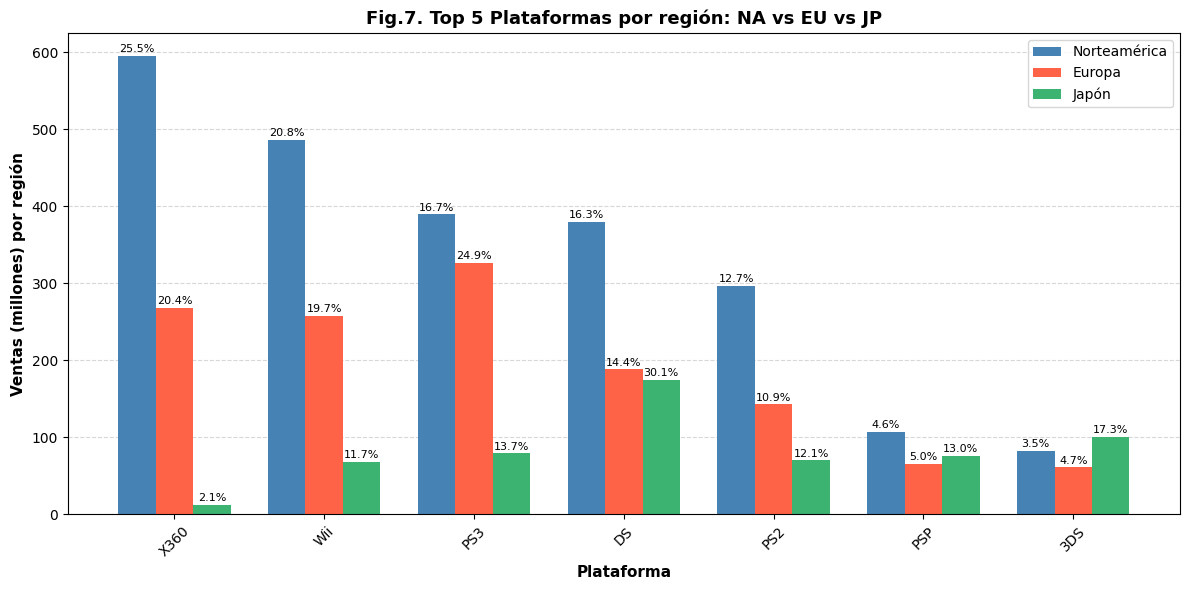

In [26]:
# Gráfica de comparación de las regiones: NA - EU - JP

# Construir DataFrame comparativo
compare_df = compare_df.sort_values('na_sales', ascending=False)

# Configuración del gráfico, posición de las barras en eje X
x = np.arange(len(compare_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, compare_df['na_sales'], width, label='Norteamérica', color= 'steelblue')
bars2 = ax.bar(x,         compare_df['eu_sales'], width, label='Europa', color='tomato')
bars3 = ax.bar(x + width, compare_df['jp_sales'], width, label='Japón', color='mediumseagreen')


# Porcentaje encima de cada barra
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
           f'{height/total_na * 100:.1f}%',
           ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
           f'{height/total_eu * 100:.1f}%',
           ha='center', va='bottom', fontsize=8)

for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{height/total_jp * 100:.1f}%',
           ha='center', va='bottom', fontsize=8)

ax.set_title('Fig.7. Top 5 Plataformas por región: NA vs EU vs JP', fontsize=13, fontweight='bold')
ax.set_xlabel('Plataforma', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventas (millones) por región', fontsize=11, fontweight='bold')
ax.set_axisbelow(True)
ax.set_xticks(x)  # define las posiciones exactas donde aparecerán las marcas (ticks) en el eje X de tu gráfico
ax.set_xticklabels(compare_df.index, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(h_pad=4) # Espacio entre imágenes
plt.show()

### Descripción de las gráficas: "Top 5 Plataformas por región: NA vs EU vs JP"

**ESTRUCTURA DEL GRAFICO**

* Eje X (horizontal): Nombres de plataformas top 5 de cada región.
* Eje Y (vertical): Ventas totales en millones por cada región.

### Análisis estadístico

* La plataforma X360 domina en Norteamérica con 25.5% (~596M), mientras que en Japón no figura en el top 5, lo que refleja un rechazo claro de ese mercado hacia consolas occidentales.

* DS es el líder absoluto en Japón con 30.1% (~175M). En NA y EU tiene una posición moderada de ~16% y ~14% respectivamente.

* 3DS y PSP son plataformas rentables en Japón con 17.3% y 13% respectivamente, mientras que no entran en el top 5 de NA ni EU.

* Japón muestra una clara preferencia por plataformas portátiles (DS, 3DS, PSP), patrón que no se repite en occidente.

* X360 y PS3 muestran fuerte competencia en NA y EU, con el X360 liderando en NA (25.5% vs 20.4%) y el PS3 liderando en EU (24.9% vs 20.4%).


### 4.2. Los 5 Géneros principales por región

In [27]:
# Agrupar por género y sumar ventas por región
genre_analys = relevant_data.groupby('genre').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum',
    'jp_sales': 'sum'
}).round(2)

# Top 5 géneros de cada región
top5_genre_na = genre_analys.sort_values('na_sales', ascending=False).head(5)
top5_genre_eu = genre_analys.sort_values('eu_sales', ascending=False).head(5)
top5_genre_jp = genre_analys.sort_values('jp_sales', ascending=False).head(5)

# Todas los top 5 en conjunto
all_top5_genre = list(set(
    top5_genre_na.index.tolist() + 
    top5_genre_eu.index.tolist() + 
    top5_genre_jp.index.tolist()
))

#Construir Dataframe comparativo
compare_genre_df  = genre_analys.loc[all_top5_genre][['na_sales', 'eu_sales', 'jp_sales']].sort_values('na_sales', ascending=False)

# Calcular total para los porcentajes por región 
total_genre_na = compare_genre_df['na_sales'].sum()
total_genre_eu = compare_genre_df['eu_sales'].sum()
total_genre_jp = compare_genre_df['jp_sales'].sum()

# Porcentajes por región
compare_genre_df['na_genre_%'] = (compare_genre_df['na_sales'] / total_genre_na * 100).round(2)
compare_genre_df['eu_genre_%'] = (compare_genre_df['eu_sales'] / total_genre_eu * 100).round(2)
compare_genre_df['jp_genre_%'] = (compare_genre_df['jp_sales'] / total_genre_jp * 100).round(2)

#Top 5 géneros

top5_genre_na = compare_genre_df.sort_values('na_sales', ascending=False).head(5)
top5_genre_eu = compare_genre_df.sort_values('eu_sales', ascending=False).head(5)
top5_genre_jp = compare_genre_df.sort_values('jp_sales', ascending=False).head(5)


print('TOP 5 GENEROS - NORTEAMERICA')
print(top5_genre_na[['na_sales', 'na_genre_%']])

print('\n TOP 5 GENEROS - EUROPA')
print(top5_genre_eu[['eu_sales', 'eu_genre_%']])

print('\n TOP 5 GENEROS - JAPON')
print(top5_genre_jp[['jp_sales', 'jp_genre_%']])

TOP 5 GENEROS - NORTEAMERICA
              na_sales  na_genre_%
genre                             
Action          619.12       25.31
Sports          471.22       19.27
Shooter         431.30       17.63
Misc            328.97       13.45
Role-Playing    233.41        9.54

 TOP 5 GENEROS - EUROPA
         eu_sales  eu_genre_%
genre                        
Action     388.60       26.27
Sports     280.47       18.96
Shooter    260.83       17.63
Misc       176.53       11.93
Racing     141.51        9.57

 TOP 5 GENEROS - JAPON
              jp_sales  jp_genre_%
genre                             
Role-Playing    193.09       37.03
Action          113.21       21.71
Misc             74.92       14.37
Sports           56.93       10.92
Platform         42.43        8.14


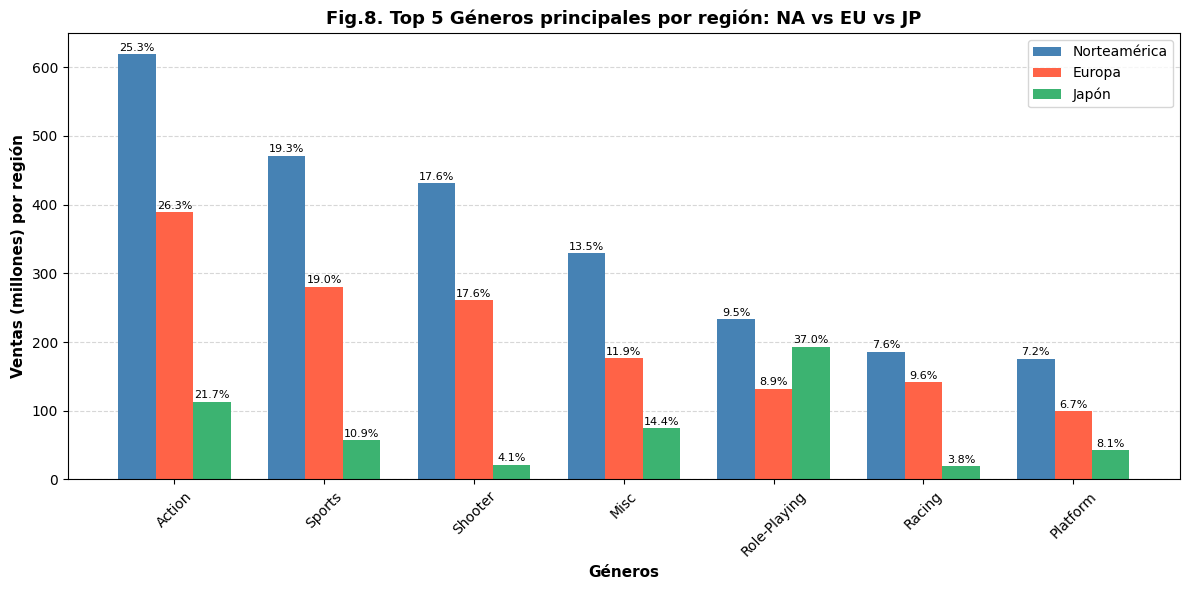

In [28]:
# Gráfica de comparaciones de los géneros de juegos en: NA - EU - JP

# Construir Dataframe comparativo
compare_genre_df = compare_genre_df.sort_values('na_sales', ascending=False)

# Configuración del gráfico, posición de las barras en eje x
x = np.arange(len(compare_genre_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1_genre = ax.bar(x - width, compare_genre_df['na_sales'], width, label='Norteamérica', color= 'steelblue')
bars2_genre = ax.bar(x,         compare_genre_df['eu_sales'], width, label='Europa', color='tomato')
bars3_genre = ax.bar(x + width, compare_genre_df['jp_sales'], width, label='Japón', color='mediumseagreen')

# Porcentaje encima de cada barra
for bar in bars1_genre:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
           f'{height/total_genre_na * 100:.1f}%',
           ha= 'center', va='bottom', fontsize=8)

for bar in bars2_genre:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
           f'{height/total_genre_eu * 100:.1f}%',
           ha= 'center', va='bottom', fontsize=8)

for bar in bars3_genre:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
           f'{height/total_genre_jp * 100:.1f}%',
           ha='center', va='bottom', fontsize=8)

ax.set_title('Fig.8. Top 5 Géneros principales por región: NA vs EU vs JP', fontsize=13, fontweight='bold')
ax.set_xlabel('Géneros', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventas (millones) por región', fontsize=11, fontweight='bold')
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(compare_genre_df.index, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(h_pad=4)
plt.show()




### Descripción de las gráficas: "Top 5 Géneros principales por región: NA vs EU vs JP"

**ESTRUCTURA DEL GRAFICO**

* Eje X (horizontal): Géneros de videojuegos presentes en el top 5 de cada región.
* Eje Y (vertical): Ventas totales en millones por región.

### Análisis estadístico

* El género Action lidera en Norteamérica y Europa con 25.3% (~619M) y 26.3% (389M aprox.) respectivamente, y ocupa el segundo lugar en Japón con 21.7% (113M aprox).

* Sports es un género fuerte en NA y EU con ventas aproximadas de 471M y 280M respectivamente, representando alrededor del 19% en ambas regiones. En Japón el consumo es significativamente menor con solo 10.9% (~57M).

* Shooter ocupa el tercer lugar en NA (431M aprox., 17.6%) y EU (261M aprox., similar proporción que NA), pero no figura en el top 5 de Japón, lo que sugiere un bajo interés de ese mercado por este género.

* Role-Playing es el género dominante en Japón con 37.03% (193M aprox.), siendo su cuota más del doble que cualquier otro género en esa región. En NA aparece en último lugar del top 5 con 9.5% (~233M) y en EU no entra entre los cinco principales.

* Norteamérica y Europa comparten preferencias similares por géneros de acción, deporte y disparos, mientras que Japón presenta un perfil completamente distinto, con una dominancia marcada del Role-Playing y ausencia total del género Shooter en su top 5. 


### 4.3. Clasificación ESRB 

In [29]:
# Lectura de la columna 'rating'
print('Clasificación ESRB disponibles:')
print(relevant_data['rating'].value_counts())

Clasificación ESRB disponibles:
rating
Sin_Clasificar    4126
E                 2942
T                 2231
E10+              1389
M                 1336
Others              10
Name: count, dtype: int64


In [30]:
# Agrupar por rating
rating_analys = relevant_data.groupby('rating').agg({
    'na_sales': ['sum', 'mean', 'count'],
    'eu_sales': ['sum', 'mean', 'count'],
    'jp_sales': ['sum', 'mean', 'count']
}).round(2)

# Agregar porcentajes
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    total_sum   = rating_analys[(region, 'sum')].sum()
    total_count = rating_analys[(region, 'count')].sum()
    rating_analys[(region, 'sum_pct_%')]   = (rating_analys[(region, 'sum')]   / total_sum   * 100).round(2)
    rating_analys[(region, 'count_pct_%')] = (rating_analys[(region, 'count')] / total_count * 100).round(2)

# Reordenar columnas correctamente
orden = ['sum', 'sum_pct_%', 'mean', 'count', 'count_pct_%']
rating_analys = rating_analys[[
    (region, col) 
    for region in ['na_sales', 'eu_sales', 'jp_sales'] 
    for col in orden
]]

# Renombrar las columnas
rating_analys.columns = pd.MultiIndex.from_tuples([
    (region, col)
    for region in ['Norteamérica', 'Europa', 'Japón']
    for col in ['total_ventas', 'ventas_%', 'promedio', 'total_juegos', 'juegos_%']
])

print('                   Clasificación ESRB en: NA vs EU vs JP')
print(rating_analys)

                   Clasificación ESRB en: NA vs EU vs JP
               Norteamérica                                          \
               total_ventas ventas_% promedio total_juegos juegos_%   
rating                                                                
E                    970.77    34.05     0.33         2942    24.45   
E10+                 345.24    12.11     0.25         1389    11.54   
M                    649.34    22.77     0.49         1336    11.10   
Others                 2.79     0.10     0.28           10     0.08   
Sin_Clasificar       355.39    12.46     0.09         4126    34.29   
T                    527.80    18.51     0.24         2231    18.54   

                     Europa                                          \
               total_ventas ventas_% promedio total_juegos juegos_%   
rating                                                                
E                    549.81    31.88     0.19         2942    24.45   
E10+               

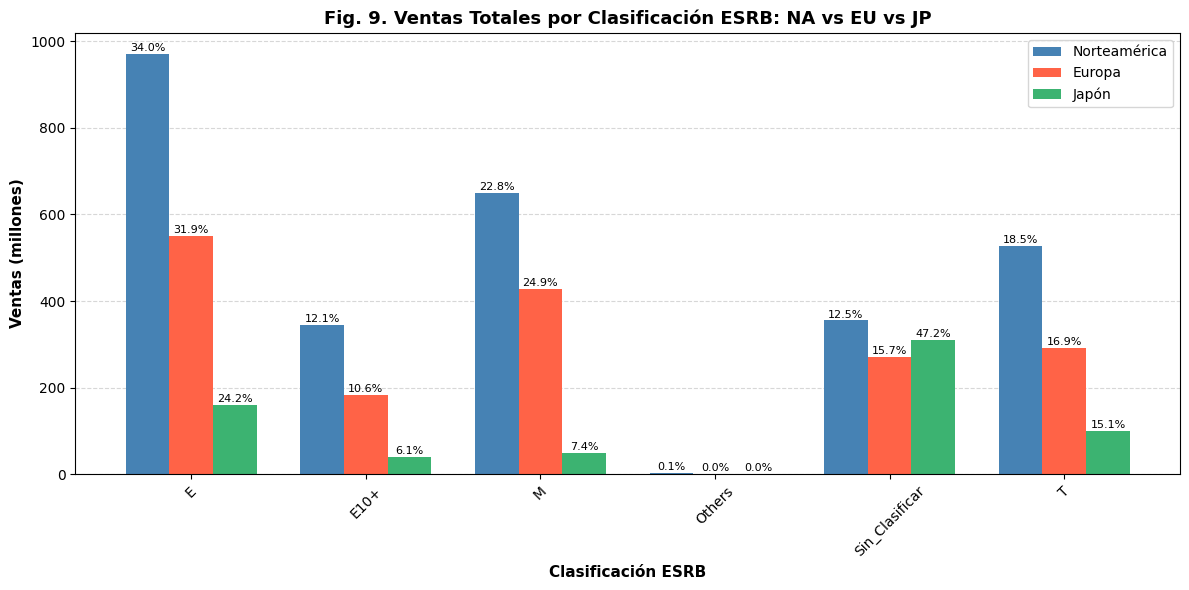

In [31]:
# Extraer solo ventas totales de cada región
plot_data_rating = rating_analys[[
    ('Norteamérica', 'total_ventas'),
    ('Europa', 'total_ventas'),
    ('Japón', 'total_ventas')
]]

plot_data_rating.columns = ['Norteamérica', 'Europa', 'Japón']

# Configuración del gráfico
x = np.arange(len(plot_data_rating))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1_rating_na = ax.bar(x - width, plot_data_rating['Norteamérica'], width, label='Norteamérica', color= 'steelblue')
bars2_rating_eu = ax.bar(x,         plot_data_rating['Europa'], width, label='Europa', color= 'tomato')
bars3_rating_jp = ax.bar(x + width, plot_data_rating['Japón'], width, label='Japón', color='mediumseagreen')

# Totales para porcentajes
total_rating_na = plot_data_rating['Norteamérica'].sum()
total_rating_eu = plot_data_rating['Europa'].sum()
total_rating_jp = plot_data_rating['Japón'].sum()

for bar in bars1_rating_na:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
           f'{height/total_rating_na * 100:.1f}%',
           ha= 'center', va='bottom', fontsize=8)

for bar in bars2_rating_eu:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
           f'{height/total_rating_eu * 100:.1f}%',
           ha = 'center', va='bottom', fontsize=8)

for bar in bars3_rating_jp:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
          f'{height/total_rating_jp * 100:.1f}%',
          ha='center', va='bottom', fontsize=8)

ax.set_title('Fig. 9. Ventas Totales por Clasificación ESRB: NA vs EU vs JP', fontsize = 13, fontweight='bold')
ax.set_xlabel('Clasificación ESRB', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventas (millones)', fontsize=11, fontweight='bold')
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(plot_data_rating.index, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Descripción de las gráficas: "Ventas Totales por clasificación ESRB: NA vs EU vs JP"

**ESTRUCTURA DEL GRAFICO**

* Eje X (horizontal): Clasificación ESRB.
* Eje Y (vertical): Ventas totales en millones.
* Clasificaciones principales:
   * **E(Everyone):** Para todas las edades.
   * **T(Teen):** 13+ años
   * **M(Mature):** 17+ años
   * **E10+ (Everyone10+):** 10+ años
   * **AO(Adults Only):** Solo adultos

### Análisis estadístico

* Los juegos clasificación E lideran en NA con 34% (aprox. 970M) y EU con 31.9% (aprox. 549M), siendo la categoría más vendida en occidente. En JP representa el 24.2% (aprox. 159M), también su segunda categoría más vendida.

* Los juegos M muestran mayor peso relativo en EU (24.9%, aprox. 428M) que en NA (22.8%, aprox. 649M), aunque en términos absolutos NA vende más. En JP esta clasificación es marginal con solo 7.4% (aprox. 48M), lo que sugiere que el mercado japonés rechaza el contenido maduro occidental.

* Sin_Clasificar domina en Japón con 47.2% (aprox. 310M), siendo su categoría con mayores ventas absolutas. En NA y EU representa entre 13-16%, lo que indica que una gran parte del catálogo japonés no sigue el sistema ESRB.

* La clasificación T muestra una tendencia descendente de occidente a oriente: NA 18.5%, EU 16.9% y JP 15.1%, con diferencias moderadas entre regiones.

* E10+ tiene presencia similar en NA (12.1%) y EU (10.6%), pero es casi irrelevante en JP (6.1%).

### Implicaciones estratégicas

Para  2017 **SEGMENTAR INVENTARIO** por región según estas preferencias:

1. **Norteamérica:** Priorizar juegos con clasificación **'E',** (34%) y **'M'** (22.8%).

2. **Europa:** Priorizar juegos con contenido **'M'** (24.9%),

3. **Japón:** Enfocarse en juegos locales o sin clasificación (47.2%) y evitar juegos de contenido **'M'** (7.4%) 

## Paso 5: Hipótesis

### 5.1. Hipótesis 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas

In [57]:
# Hipótesis 1
# Filtrar datos
xone_data = relevant_data[relevant_data['platform'] ==  'XOne']
pc_data = relevant_data[relevant_data['platform'] == 'PC']

# Extraer calificaciones de usuarios y Eliminar valores ausentes
xone_user_score = xone_data['user_score'].dropna()
pc_user_score = pc_data['user_score'].dropna()

print('PRUEBA DE HIPOTESIS: Las calificaciones promedio de usuarios')
print('                      son iguales entre estas plataformas')
print('H₀ (nula): Las calificaciones promedio son iguales')
print('H₁ (alternativa): Las calificaciones promedio son diferentes')
print('Nivel de significancia: α = 0.05')
print('-' * 50)

#Estadística descriptiva
print(f'Tamaño de muestra XOne  : {len(xone_user_score)}')
print(f'Tamaño de muestra PC    : {len(pc_user_score)}')
print(f'Promedio XOne           : {xone_user_score.mean():.2f}')
print(f'Promedio PC             : {pc_user_score.mean():.2f}')
print(f'Diferencia (PC - Xone)  : {pc_user_score.mean() - xone_user_score.mean():.2f}')
print('-' * 50)

# Verificar varianzas para justificar el uso de Welch's t-test
print(f"Varianza Xone:      {xone_user_score.var():.2f}")
print(f"Varianza PC:        {pc_user_score.var():.2f}")
print(f"Ratio de varianzas: {xone_user_score.var() / pc_user_score.var():.2f}")
print(f'Usando Welch t-test: muestras de tamaños muy diferentes {len(xone_user_score)} vs {len(pc_user_score)}')
print('-' * 50)

# 1er prueba Welch's t-test
alpha = 0.05
hipotesis_1 = st.ttest_ind(xone_user_score, pc_user_score, equal_var=False)

# Mostrar resultados
print(f"Estadístico t: {hipotesis_1.statistic:.2f}")
print(f"P-valor :      {hipotesis_1.pvalue:.2e}")
print("-" * 50)

# Interpretación
if hipotesis_1.pvalue < alpha:
    print('CONCLUSIÓN: Rechazamos la hipótesis nula')
    print('   Existe diferencia estadísticamente significativa entre las')
    print('   calificaciones promedio de las plataformas Xbox One y PC.')
else:
    print('CONCLUSIÓN: No podemos rechazar la hipótesis nula')
    print('   Las calificaciones promedio de XOne y PC son IGUALES.')

PRUEBA DE HIPOTESIS: Las calificaciones promedio de usuarios
                      son iguales entre estas plataformas
H₀ (nula): Las calificaciones promedio son iguales
H₁ (alternativa): Las calificaciones promedio son diferentes
Nivel de significancia: α = 0.05
--------------------------------------------------
Tamaño de muestra XOne  : 182
Tamaño de muestra PC    : 670
Promedio XOne           : 6.52
Promedio PC             : 6.92
Diferencia (PC - Xone)  : 0.40
--------------------------------------------------
Varianza Xone:      1.91
Varianza PC:        2.32
Ratio de varianzas: 0.82
Usando Welch t-test: muestras de tamaños muy diferentes 182 vs 670
--------------------------------------------------
Estadístico t: -3.38
P-valor :      8.31e-04
--------------------------------------------------
CONCLUSIÓN: Rechazamos la hipótesis nula
   Existe diferencia estadísticamente significativa entre las
   calificaciones promedio de las plataformas Xbox One y PC.


### Análisis estadístico

* **Hipótesis 1: Calificaciones promedio de usuarios - XOne vs PC**

**Planteamiento:** Se busca determinar si existe una diferencia estadísticamente significativa entre las calificaciones promedio que los usuarios otorgan a juegos en XOne y PC.
   * H₀: Las calificaciones promedio de XOne y PC SON IGUALES.
   * H₁: Las calificaciones promedio de XOne y PC SON DIFERENTES.
   * Nivel de significancia: α = 0.05

**Estadísticas descriptivas:**

XOne presenta una muestra de 182 juegos con un promedio de 6.52, mientras que PC cuenta con 670 juegos y un promedio de 6.92, una diferencia de 0.40 puntos a favor de PC.

**Justificación del test:**

Se aplicó el Welch t-test (equal_var=False) en lugar del t-test estándar, debido a la gran diferencia en tamaño de muestras 182 vs 670. Aunque el ratio de varianzas es de 0.82 es cercano a 1, el Welch t-test maneja mejor la situación cuando los dos grupos tienen tamaño muy distintos y ajusta los grados de libertad para compensar ese desequilibrio.

**Resultado:**

1. Con un estadístico t= -3.38 y un p-valor= 0.000831(8.31e-04), el p-valor es significativamente menor que α = 0.05.

2. Se rechaza la hipótesis nula, existe evidencia estadísticamente significativa de que las calificaciones promedio de los usuarios para XOne(6.52) y PC(6.92) son diferentes siendo PC la plataforma con mejor valoración promedio por parte de los usuarios.


### 5.2. Hipótesis 2: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [70]:
# Hipótesis 2 
# Filtrar datos
action_data = relevant_data[relevant_data['genre'] == 'Action']
sports_data = relevant_data[relevant_data['genre'] == 'Sports']

# Extraer calificaciones de usuarios y eliminar valores ausentes
action_user_score = action_data['user_score'].dropna()
sports_user_score = sports_data['user_score'].dropna()

print("PRUEBA DE HIPOTESIS: Las calificaciones promedio de ususarios")
print("                      son iguales entre estos géneros")
print("H₀ (nula): Las calificaciones promedio son iguales")
print("H₁ (alternativa): Las calificaciones son promedio son diferentes")
print("Nivel de significancia: α = 0.05")
print("-" * 50)

# Estadística descriptiva
print(f"Tamaño de muestra Action    : {len(action_user_score)}")
print(f"Tamaño de muestra Sports    : {len(sports_user_score)}")
print(f"Promedio Action             : {action_user_score.mean():.2f}")
print(f"Promedio Sports             : {sports_user_score.mean():.2f}")
print(f"Diferencia (Action - Sports): {action_user_score.mean() - sports_user_score.mean():.2f}")
print("-" * 50)

# Verificar varianzas para justificar el uso de Welch's t-test
print(f"Varianza Action:        {action_user_score.var():.2f}")
print(f"Varianza Sports:        {sports_user_score.var():.2f}")
print(f"Ratio de varianzas:     {action_user_score.var() / sports_user_score.var():.2f}")
print(f"Usando Welch t-test: muestras de tamaños muy diferentes {len(action_user_score)} vs {len(sports_user_score)}")
print("-" * 50)

# 1er prueba Welch's t-test
alpha = 0.05
hipotesis_2 = st.ttest_ind(action_user_score, sports_user_score, equal_var=False)

# Mostrar resultados
print(f"Estadística t: {hipotesis_2.statistic:.2f}")
print(f"p-valor :      {hipotesis_2.pvalue:.2e}")
print("-" * 50)

# Interpretación

if hipotesis_2.pvalue < alpha:
    print('CONCLUSIÓN: Rechazamos la hipótesis nula')
    print('   Existe diferencia estadísticamente significativa entre las')
    print('   calificaciones promedio de los géneros Action y Sports.')
else:
    print('CONCLUSIÓN: No podemos rechazar la hipótesis nula')
    print('   Las calificaciones promedio de Action y Sports son IGUALES.')
    

PRUEBA DE HIPOTESIS: Las calificaciones promedio de ususarios
                      son iguales entre estos géneros
H₀ (nula): Las calificaciones promedio son iguales
H₁ (alternativa): Las calificaciones son promedio son diferentes
Nivel de significancia: α = 0.05
--------------------------------------------------
Tamaño de muestra Action    : 1550
Tamaño de muestra Sports    : 831
Promedio Action             : 6.98
Promedio Sports             : 6.68
Diferencia (Action - Sports): 0.31
--------------------------------------------------
Varianza Action:        1.88
Varianza Sports:        2.72
Ratio de varianzas:     0.69
Usando Welch t-test: muestras de tamaños muy diferentes 1550 vs 831
--------------------------------------------------
Estadística t: 4.56
p-valor :      5.55e-06
--------------------------------------------------
CONCLUSIÓN: Rechazamos la hipótesis nula
   Existe diferencia estadísticamente significativa entre las
   calificaciones promedio de los géneros Action y Spor

### Análisis estadístico

* **Hipótesis 2: Calificaciones promedio de usuarios - Action vs Sports**

**Planteamiento:** Se busca determinar si existe una diferencia estadísticamente significativa entre las calificaciones promedio que los usuarios otorgan a juegos de géneros Action y Sports.

   * H₀: Las calificaciones promedio de Action y Sports SON IGUALES.
   * H₁: Las calificaciones promedio de Action y Sports SON DIFERENTES.
   * Nivel de significancia: α = 0.05

**Estadística descriptiva**

Action presenta una muestra de 1550 juegos con un promedio de 6.98, mientras que Sports cuenta con 831 juegos y un promedio de 6.68, una diferencia de 0.31 puntos a favor de Action.

**Justificación de test:**

Se aplicó el Welch's t-test (equal_var=False) en lugar del t-test estándar por dos razones. 

   * Primero, los tamaños de muestra son considerablemente desiguales 1550 vs 831, y el Welch's t-test ajusta automáticamente los grados de libertad para compensar ese desequilibrio.
   
   * Segundo, el ratio de varianzas de 0.69 indica una diferencia moderada entre las varianzas de ambos grupos, lo que refuerza la decisión de no asumir varianzas iguales como lo haría el t-test estándar.


**Resultado:**

   1. Con un estadístico t= 4.56 y un p-valor= 0.0000055 (5.55e-06), el p-valor es significativamente menor que 0.05.
   
   2. Se rechaza la hipótesis nula, existe evidencia estadísticamente significativa de que las calificaciones promedio de los usuarios para Action (6.98) y Sports (6.68) son diferentes, siendo Action el género con mayor valoración promedio por parte de los usuarios.



## Paso 5: Conclusión 

**1. Tiempos de transición generacional**
    
  * Un nuevo ciclo generacional tarde entre 6 y 7 años, con un periodo de convivencia de hasta 5 años entre generaciones, esto significa que para 2017 las plataformas de 8ª generación (PS4, XOne) están en pleno apogeo y aún tienen varios años de vida comercial por delante. 

**2. Determinación del período de datos relevantes** 

  * El período seleccionado para el análisis fue 2004-2016, este período ofrece el balance óptimo entre volumen de datos y relevancia comercial; usar datos anteriores a 2004 habría introducido ruido de plataformas obsoletas, distorsionando las tendencias actuales.

      2.1. Completitud de datos: Los años 2015 y 2016 posiblemente presenten datos incompletos al momento del análisis, por lo que sus cifras podrían subestimar la actividad real del mercado.

      2.2. Actividad de mercado: Este período concentra los picos más altos de las plataformas de 7ª y 8ª generación, con PS2, Wii, DS, X360, PS3 y PS4 como las más destacadas.

**3. Plataformas potencialmente rentables para 2017**

  * PS4 es la plataforma más sólida con crecimiento sostenido desde 2013 y con el mejor promedio de ventas por juego con 10.4M, lo que lo convierte en la apuesta más segura para 2017.

  * X360 es el competidor más directo del PS4 con 0.87M por juego, manteniendo una base de usuarios fieles especialmente en Norteamérica.

  * Para 2017 se recomienda concentrar inversión en:

    * PS4 y X360 como plataformas principales en Norteamérica y Europa; y Japón que muestran una clara preferencia por plataformas portátiles como DS y 3DS.
      
    * PC y 3DS como mercados secundarios estables. Las plataformas de 7ª generación deben considerarse solo para títulos de bajo costo de desarrollo.


**4. Géneros más rentables por juego**

  * Los géneros Shooter y Platform ofrecen el mejor retorno por título publicado. Action es rentable en volumen pero competitivo. Para Japón, Role-Playing es la apuesta más segura de mercado.

     4.1. "Rentabilidad ALTA" por juego
   
       * Los géneros más rentables con un rango de promedio por juego están 'Shooter'(0.87M), 'Platform'(0.72M) y 'Sports'(0.62M), son los géneros más eficientes comercialmente, generando mayores ingresos por título público.

     4.2. "Rentabilidad MEDIA" por juego
   
       * Racing, Role-Playing, Action, Fighting, Misc y Simulation; con un promedio entre 0.42M - 0.57M, aunque Action tiene el mayor volumen con 2699 juegos su rentabilidad es moderada debido a la saturación del mercado. Por otro lado Role-Playing mantiene una base fiel de usuarios especialmente en Japón.


**5. Clasificación ESRB por región**

  * Una estrategia de clasificación única para todas las regiones sería ineficiente. Japón requiere una estrategia completamente diferenciada respecto a occidente.
    
  * La clasificación ESRB tiene un impacto directo en las ventas según la región, por lo que se recomienda segmentar el inventario así:

     5.1. Norteamérica: Priorizar juegos con clasificación 'E', (34%) y 'M' (22.8%). El mercado norteamericano acepta tanto contenido familiar como maduro.

     5.2. Europa: Priorizar juegos con contenido 'M' (24.9%) y 'E' (31.9%). Europa muestra ligera preferencia por contenido maduro respecto a NA.

     5.3. Japón: Enfocarse en títulos locales o sin clasificación ESRB (47.2%) y reducir inversión en contenido M (7.4%), ya que el mercado japonés mayoritariamente no sigue el sistema ESRB y rechaza el contenido maduro occidental.

**6. Validación estadística de hipótesis**

  * Las diferencias detectadas son estadísticamente reales y no producto del azar, lo que respalda las recomendaciones de inversión por plataforma y género descritas en los puntos siguientes:
    
    **6.1. Hipótesis 1 — XOne vs PC:** Existe diferencia estadísticamente significativa entre las calificaciones promedio de usuarios de Xbox One (6.52) y PC (6.92), con p-valor = 8.31e-04 < 0.05. PC recibe mejores valoraciones, posiblemente por su mayor flexibilidad técnica y comunidad de usuarios más exigente.

     **6.2. Hipótesis 2 — Action vs Sports:** Existe diferencia estadísticamente significativa entre las calificaciones promedio de Action (6.98) y Sports (6.68), con p-valor = 5.55e-06 < 0.05. Los usuarios valoran más los juegos de Action que los de Sports, aunque ambos géneros son comercialmente fuertes en ventas totales.